# Aerobicity: phenotype prediction, feature selection, and data visualization

This notebook provides a pipeline for predicting the aerobicity phenotype and identifying genome footprints. 

We train and test XGBoost classifier on COG count tables, that are split into the test and train ones at a specified taxonomy level (i.e. all samples from a taxonomy group go to either train or test). The notebook can be run for one taxonomy level split. 

To identify genome footprints and the most important features (COGs) contributing to the phenotype prediction, we use three different feature selection ranking methods:

- calculating the mutual information between the feature and the target label vector,
- using the feature weights returned by the random forest model,
- calculating SHAP values using the pre-trained XGBoost model.

The predictions of those three methods are compared between each other at the end of the notebook. 

#### 1. Read the train and test datasets

First, we read the input files generated by *taxa_level_split.py*. The script generates 6 output files for the chosen [tax_level] of the train/test split, that are used as main inputs in this notebook. The files are the following:

- train_data_[tax_level]_tax_level : training count table,
- train_annot_[tax_level]_tax_level : training annotations,
- train_taxa_names_[tax_level]_tax_level : [tax_level] name of each training sample,

\+ 3 similar test tables. Those files should be stored in the corresponding directory for the phenotype.

In order to run the phenotype prediction pipeline in this notebook, the data directory with the input files, and [tax_level] of the train/test split should be specified below.

In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from utils.utils import read_sporulat_data, pca_run_and_plot, tsne_plot

TAX_LEVEL = "phylum"  # <----------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_sporulation"  # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <-------------- number of splits to read and process is here!!

RANDOM_SEED = 42
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [44]:
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_train, y_label_train, X_column_names, taxa_group_names_train = read_sporulat_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE)
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}"  if TAX_LEVEL != "random" else None
    X_val_test, y_label_test, X_column_names, taxa_group_names_test = read_sporulat_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE)

    print(f"spor in train = {sum(y_label_train)/len(y_label_train)}")
    print(f"spor in test = {sum(y_label_test)/len(y_label_test)}")

    X_val_train = (X_val_train > 0).int()
    X_val_test = (X_val_test > 0).int()
    
    curr_split_dict = defaultdict(str)
    curr_split_dict["X_train"] = X_val_train
    curr_split_dict["y_train"] = y_label_train
    curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
    curr_split_dict["X_test"] = X_val_test
    curr_split_dict["y_test"] = y_label_test
    curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
    curr_split_dict["feature_names"] = X_column_names

    all_splits_dict[split_id] = curr_split_dict

spor in train = 0.11099949479103088
spor in test = 0.3235724866390228
spor in train = 0.16612553596496582
spor in test = 0.16343826055526733
spor in train = 0.17863894999027252
spor in test = 0.11469534039497375
spor in train = 0.2600000202655792
spor in test = 0.09383202344179153
spor in train = 0.1736045479774475
spor in test = 0.1339285671710968
spor in train = 0.16064690053462982
spor in test = 0.17582418024539948
spor in train = 0.11047346144914627
spor in test = 0.361921101808548
spor in train = 0.10518934577703476
spor in test = 0.4056074917316437
spor in train = 0.1402352899312973
spor in test = 0.26229506731033325
spor in train = 0.10794297605752945
spor in test = 0.3239436447620392
spor in train = 0.27057358622550964
spor in test = 0.007476635742932558
spor in train = 0.19823789596557617
spor in test = 0.1410006582736969
spor in train = 0.08399602025747299
spor in test = 0.4123867154121399
spor in train = 0.11573849618434906
spor in test = 0.3333333432674408
spor in train = 0

In [43]:
all_splits_dict.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [3]:
print(X_val_train.shape)

torch.Size([1958, 4789])


Next, we find the percentage of aerobs and anaerobs in the train and test datasets. We need to make sure that there is no huge data disbalance between the aerobs/anaerobs classes and between the train/test datasets.

## Find/read Markov Blankets for each split in the data

In [5]:
# import warnings
# import re 

# warnings.filterwarnings(
#     "ignore",
#     category=FutureWarning,
#     message="Your system has an old version of glibc.*"
# )

# # Suppress KBinsDiscretizer quantile method deprecation warning
# warnings.filterwarnings(
#     "ignore",
#     category=FutureWarning,
#     message="The current default behavior, quantile_method='linear'.*"
# )

# # Suppress constant feature replacement warning
# warnings.filterwarnings(
#     "ignore",
#     category=UserWarning,
#     message="Feature .* is constant and will be replaced with 0"
# )
# warnings.filterwarnings("ignore", message="Note: You have installed the 'manylinux2014' variant of XGBoost")
# warnings.filterwarnings("ignore", message="Your system has an old version of glibc", category=FutureWarning)
# warnings.filterwarnings("ignore", message="The number of unique classes is greater than 50% of the number of samples.", category=UserWarning)
# warnings.filterwarnings("ignore", category=FutureWarning,
#     message=re.escape("Your system has an old version of glibc"))
# warnings.filterwarnings("ignore", category=UserWarning,
#     message=re.escape("The number of unique classes is greater than 50%"))

In [45]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from feature_selection.feature_selection_utils import iamb
import warnings
from sklearn.preprocessing import KBinsDiscretizer
import json

filename = f"{OUTPUT_DIRECTORY}/markov_boundaries.json"
all_markov_bound_dict = defaultdict(int)


if os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_markov_bound_dict = json.load(f)

else:
    for split_id in range(NUM_SPLITS_TO_READ):
        print(f"Processing split {split_id}")
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]

        mutual_info = mutual_info_classif(X_val_train.cpu(), y_label_train.cpu(), random_state=42)
        sorted_indices = np.argsort(mutual_info)[::-1] 
        N = 500
        top_N_indices = sorted_indices[:N]
        
        X_np = X_val_train.cpu().numpy().astype(int)   
        y_np = y_label_train.cpu().numpy().astype(int)  
    
        # Suppress only the specific warning from KBinsDiscretizer about small bin widths
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Bins whose width are too small")

            X_np = (X_np > 0).astype(int)
            
            # Discretize remaining features
           # disc = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile')
           # X_disc = disc.fit_transform(X_np)
        
            selected_columns = [f"{X_column_names[i]}" for i in range(X_np.shape[1])]
            X_filtered = pd.DataFrame(X_np, columns=np.array(selected_columns))#[selector.get_support()])

            X_filtered = X_filtered.iloc[:, top_N_indices]
            print(X_filtered.shape)
            
            markov_boundary = iamb(X_filtered, y_np, alpha=0.01, verbose=False)
        print("Markov Boundary:", markov_boundary)
    
        all_markov_bound_dict[split_id] = markov_boundary


    with open(filename, "w") as f:
        json.dump(dict(all_markov_bound_dict), f, indent=2)

Reading the existing file...


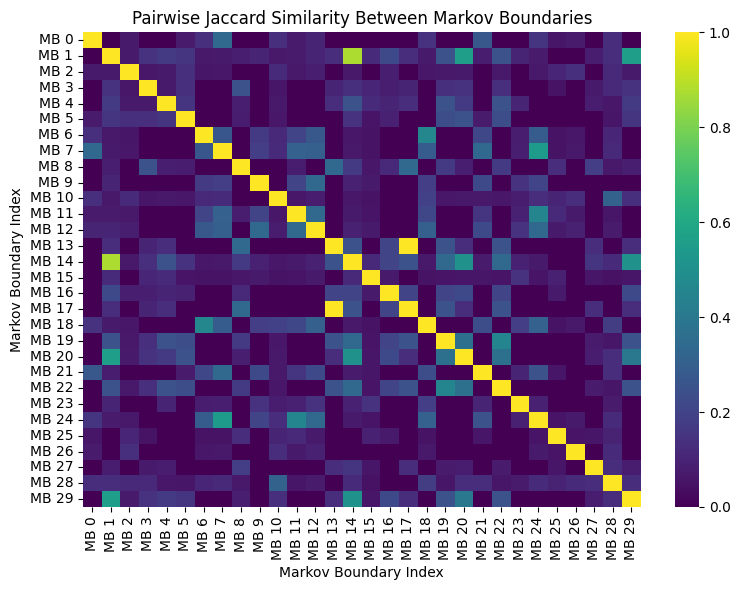

In [7]:
import seaborn as sns
from itertools import combinations
import pandas as pd

markov_boundaries = []

for split_id in all_markov_bound_dict.keys():
    markov_boundaries.append(set(all_markov_bound_dict[split_id])) 
# Number of sets
n = len(markov_boundaries)

# Compute pairwise Jaccard similarity matrix
jaccard_matrix = np.zeros((n, n))
jacc_idices = []
for i in range(n):
    for j in range(n):
        a, b = markov_boundaries[i], markov_boundaries[j]
        union = a | b
        intersection = a & b
        jaccard_index = len(intersection) / len(union) if union else 0
        jaccard_matrix[i, j] = jaccard_index
        if i>j:
            jacc_idices.append(jaccard_index)
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_matrix, annot=False, fmt=".2f", cmap="viridis", cbar=True,
            xticklabels=[f"MB {i}" for i in range(n)],
            yticklabels=[f"MB {i}" for i in range(n)])
plt.title("Pairwise Jaccard Similarity Between Markov Boundaries")
plt.xlabel("Markov Boundary Index")
plt.ylabel("Markov Boundary Index")
plt.tight_layout()
plt.show()


In [8]:
num_splits = len(all_markov_bound_dict.keys())

all_cogs = sorted(set(cog for lst in all_markov_bound_dict.values() for cog in lst))
presence_df = pd.DataFrame(0, index=all_cogs, columns=[f"Split_{i}" for i in all_markov_bound_dict])
for i, cogs in all_markov_bound_dict.items():
    presence_df.loc[cogs, f"Split_{i}"] = 1

# Add frequency column
presence_df["Frequency"] = presence_df.sum(axis=1)/num_splits

# Sort by frequency
presence_df_sorted = presence_df.sort_values("Frequency", ascending=False)



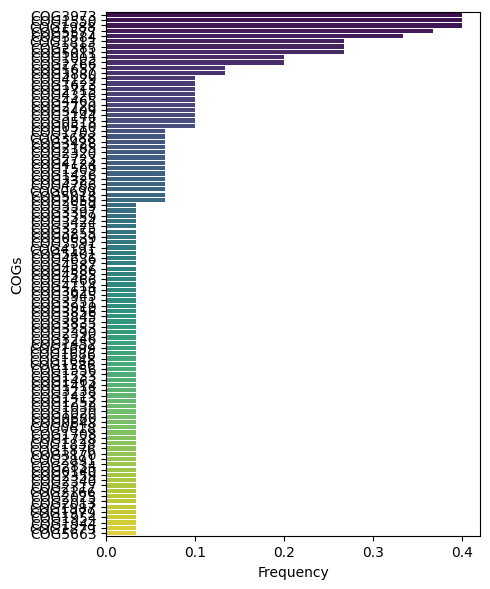

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(5, 6))
sns.barplot(
    x="Frequency",
    y=presence_df_sorted.index,
    data=presence_df_sorted.reset_index(),
    hue="index",  # use index as hue to apply the palette
    palette="viridis",
    dodge=False,
    legend=False
)
plt.xlabel("Frequency")
plt.ylabel("COGs")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/markov_boundar_cogs.pdf", format="pdf")

In [10]:
dict_mb_stats = defaultdict(str)
dict_mb_stats["jaccard_aver"] = np.mean(jacc_idices)
dict_mb_stats["jaccard_std"] = np.std(jacc_idices)
print(f"Ave. Jaccard indec = {np.mean(jacc_idices)}; std = {np.std(jacc_idices)}")

Ave. Jaccard indec = 0.08966734013093575; std = 0.12111546281567923


In [11]:
from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features


all_markov_bound_dict_with_res = {}#defaultdict(int)
mb_lengths = []

for split_id in all_markov_bound_dict.keys():
    mb_lengths.append(len(all_markov_bound_dict[split_id]))
    markov_bound = all_markov_bound_dict[split_id]
    indices = [i for i, val in enumerate(X_column_names) if val in markov_bound]
    
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
    split_dict = defaultdict(str)
    split_dict["MB"] = markov_bound[:]
    # split_dict["cv_accuracy_scores"] = cv_accuracy_scores
    # split_dict["test_accuracy_scores"] = test_accuracy_scores
    all_markov_bound_dict_with_res[split_id] = split_dict

print(f"Average MB length = {np.mean(mb_lengths)}; std = {np.std(mb_lengths)}")    

Average MB length = 7.4; std = 2.511307760244982


In [12]:
dict_mb_stats["mb_length_aver"] = np.mean(mb_lengths)
dict_mb_stats["mb_length_std"] = np.std(mb_lengths)
df = pd.DataFrame([dict_mb_stats])

# Save to CSV
df.to_csv(f"{OUTPUT_DIRECTORY}/mb_summary.csv", index=False)

In [13]:
import math

aver_mb_len = math.ceil(np.mean(mb_lengths))
aver_m_names = presence_df_sorted.index[:aver_mb_len].tolist()

with open(f"{OUTPUT_DIRECTORY}/aver_mb.txt", "w") as f:
    f.write(f"{aver_m_names}\n")
        
aver_m_names

['COG3973',
 'COG1550',
 'COG1988',
 'COG5577',
 'COG3584',
 'COG1813',
 'COG2385',
 'COG5011']

## Check performance on MBs

In [14]:
# Calculate the baseline accuracies 
test_accur_dict_splits_baseline = defaultdict(list)
for split_id in all_splits_dict.keys():
   # print(f"Processing {split_id} split...")
    X_val_train = all_splits_dict[int(split_id)]["X_train"]
    y_label_train = all_splits_dict[int(split_id)]["y_train"]
    X_val_test = all_splits_dict[int(split_id)]["X_test"]
    y_label_test = all_splits_dict[int(split_id)]["y_test"]
    taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]

    #Calculate the baseline accuracies
    N_tot = len(y_label_test)
    N_1 = sum(y_label_test).item()
    N_0 = N_tot - N_1
    fp = tn = N_0 / 2
    tp = fn = N_1 / 2
    
    if tp + fn > 0:
        pres = tp / (tp + fp)
        recall = tp / (tp + fn)
        f1 = 2 * (pres * recall) / (pres + recall)
        
        # Accuracy
        accuracy = (tp + tn) / N_tot
        
        # Matthews correlation coefficient
        numerator = (tp * tn) - (fp * fn)
        denominator = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
        mcc = numerator / denominator if denominator != 0 else 0
        
        # Append to dict
        test_accur_dict_splits_baseline["accuracy"].append(accuracy)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        test_accur_dict_splits_baseline["roc_auc"].append(0)
        test_accur_dict_splits_baseline["mcc"].append(mcc)

test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in test_accur_dict_splits_baseline.keys():
    #Baseline
    test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])
metrics_baseline = {"test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
metrics_baseline        

{'test baseline mean': defaultdict(float,
             {'accuracy': 0.5,
              'precision': 0.21780889224337388,
              'recall': 0.5,
              'f1': 0.28141774352911847,
              'roc_auc': 0.0,
              'mcc': 0.0}),
 'test baseline std': defaultdict(float,
             {'accuracy': 0.0,
              'precision': 0.12147818065937736,
              'recall': 0.0,
              'f1': 0.13226984682539517,
              'roc_auc': 0.0,
              'mcc': 0.0})}

In [15]:
# Explore the accuracies on different MB
from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

def find_accuracies_on_restricted_feat_space(all_splits_dict, feature_condit):
    cv_accur_dict_splits = defaultdict(list)
    test_accur_dict_splits = defaultdict(list)
    print(f"Processing splits...")
    for split_id in all_markov_bound_dict_with_res.keys():
        split_id = str(split_id)
       # print(split_id)
        X_val_train = all_splits_dict[int(split_id)]["X_train"]
        y_label_train = all_splits_dict[int(split_id)]["y_train"]
        X_val_test = all_splits_dict[int(split_id)]["X_test"]
        y_label_test = all_splits_dict[int(split_id)]["y_test"]
    
        taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]
        mbs = all_markov_bound_dict_with_res[split_id]['MB']

        if feature_condit == "mb_train_test":
            indices = [i for i, val in enumerate(X_column_names) if val in mbs]
            cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
        elif feature_condit == "mb_zero_test":
            indices = [i for i, val in enumerate(X_column_names) if val in mbs]
            X_val_test_mod = X_val_test.clone()
            X_val_test_mod[:, indices] = 0
            cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test_mod, y_label_test, DEVICE, groups=taxa_group_names_train)    
        elif feature_condit == "full":
            cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
        elif feature_condit == "no_mb_train_test":
            indices = [i for i, val in enumerate(X_column_names) if val not in mbs]
            cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
        elif feature_condit == "no_mb_test":
            indices = [i for i, val in enumerate(X_column_names) if val not in mbs]
            X_val_test_mod = X_val_test.clone()
            X_val_test_mod[:, indices] = 0
            cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test_mod, y_label_test, DEVICE, groups=taxa_group_names_train)        
        else:
            print(f"Wrong feature_condit!")

        for accur_measure in cv_accuracy_scores.keys():
            cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
            test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])
    
    cv_accur_dict_mean = defaultdict(float)
    cv_accur_dict_std = defaultdict(float)
    test_accur_dict_mean = defaultdict(float)
    test_accur_dict_std = defaultdict(float)
    for accur_measure in cv_accur_dict_splits.keys():
        #CV
        cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
        cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
        # Test
        test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
        test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    print(f"Done!")    
    return cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std

In [16]:
# MB on both train and test
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, "mb_train_test")
metrics_mb_train_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# MB on test only
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, "mb_zero_test")
metrics_mb_zero_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# Full feat set
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, "full")
metrics_full = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# (Full - MB) on both train and test
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, "no_mb_train_test")
metrics_no_mb_train_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# (Full - MB) on test only
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, "no_mb_test")
metrics_no_mb_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}


Processing splits...


C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\cupy\_environment.py:217: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classi

Done!
Processing splits...


C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

Done!
Processing splits...


...

Done!
Processing splits...


C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

Done!
Processing splits...


C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kolda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

Done!


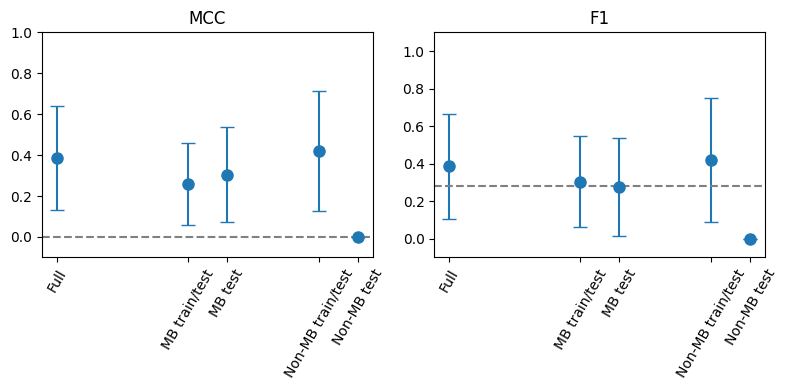

In [20]:
x = [0, 1, 1.3, 2, 2.3]
xtick_labels = ['Full', 'MB train/test', 'MB test', 'Non-MB train/test', 'Non-MB test']


plt.figure(figsize=(8,4))
#MCC
plt.subplot(1, 2, 1)
plt.errorbar([0], metrics_full['test mean']['mcc'], yerr=metrics_full['test std']['mcc'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([1], metrics_mb_train_test['test mean']['mcc'], yerr=metrics_mb_train_test['test std']['mcc'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([1.3], metrics_mb_zero_test['test mean']['mcc'], yerr=metrics_mb_zero_test['test std']['mcc'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([2], metrics_no_mb_train_test['test mean']['mcc'], yerr=metrics_no_mb_train_test['test std']['mcc'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([2.3], metrics_no_mb_test['test mean']['mcc'], yerr=metrics_no_mb_test['test std']['mcc'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.axhline(y=metrics_baseline['test baseline mean']['mcc'], color='grey', linestyle='--', label='Baseline')  # horizontal
plt.xticks(ticks=x, labels=xtick_labels, rotation=60)
plt.ylim(-0.1, 1)
#plt.ylabel('Accuracy')
plt.title('MCC')

#F1
plt.subplot(1, 2, 2)
plt.errorbar([0], metrics_full['test mean']['f1'], yerr=metrics_full['test std']['f1'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([1], metrics_mb_train_test['test mean']['f1'], yerr=metrics_mb_train_test['test std']['f1'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([1.3], metrics_mb_zero_test['test mean']['f1'], yerr=metrics_mb_zero_test['test std']['f1'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([2], metrics_no_mb_train_test['test mean']['f1'], yerr=metrics_no_mb_train_test['test std']['f1'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.errorbar([2.3], metrics_no_mb_test['test mean']['f1'], yerr=metrics_no_mb_test['test std']['f1'], fmt='o', capsize=5, markersize=8, color='tab:blue')
plt.axhline(y=metrics_baseline['test baseline mean']['f1'], color='grey', linestyle='--', label='Baseline')  # horizontal
plt.xticks(ticks=x, labels=xtick_labels, rotation=60)
plt.ylim(-0.1, 1.1)
#plt.ylabel('Accuracy')
plt.title('F1')
plt.tight_layout()

plt.show()

In [2]:
# # Explore the accuracies on the averaged MB
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# acuracy_across_mb = defaultdict(list)

# for i in range(1, len(aver_m_names) + 1):
#     print(f"Processing {i} i...")
#     cv_accur_dict_splits = defaultdict(list)
#     test_accur_dict_splits = defaultdict(list)
#     test_accur_dict_splits_baseline = defaultdict(list)
#     for split_id in all_splits_dict.keys():
#         X_val_train = all_splits_dict[split_id]["X_train"]
#         y_label_train = all_splits_dict[split_id]["y_train"]
#         X_val_test = all_splits_dict[split_id]["X_test"]
#         y_label_test = all_splits_dict[split_id]["y_test"]
    
#         taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]
#         aver_m_names_local = aver_m_names[:i]
#         indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names_local]
#         cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
        
#        # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#         for accur_measure in cv_accuracy_scores.keys():
#             cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#             test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])
    
#         #Calculate the baseline accuracies
#         N_tot = len(y_label_test)
#         N_1 = sum(y_label_test).item()
#         N_0 = N_tot - N_1
#         fp = tn = N_0/2
#         tp = fn = N_1/2
    
#         if tp+fn >0:
#             pres = tp/(tp+fp)
#             recall = tp/(tp+fn)
#             f1 = 2*(pres*recall)/(pres+recall)
        
#             test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#             test_accur_dict_splits_baseline["precision"].append(pres)
#             test_accur_dict_splits_baseline["recall"].append(recall)
#             test_accur_dict_splits_baseline["f1"].append(f1)
#             test_accur_dict_splits_baseline["roc_auc"].append(0)
            
    
#     cv_accur_dict_mean = defaultdict(float)
#     cv_accur_dict_std = defaultdict(float)
#     test_accur_dict_mean = defaultdict(float)
#     test_accur_dict_std = defaultdict(float)
#     test_accur_dict_splits_baseline_mean = defaultdict(float)
#     test_accur_dict_splits_baseline_std = defaultdict(float)
#     for accur_measure in cv_accur_dict_splits.keys():
#         cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#         cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#         test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#         test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    
#         test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#         test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

#     metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
#     acuracy_across_mb[i] = metrics



# df = pd.DataFrame(acuracy_across_mb)
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_across_aver_mb.csv")

# print(df)

In [3]:
# for i in acuracy_across_mb.keys():
#     plt.errorbar(
#     i,
#     acuracy_across_mb[i]['cv mean']['f1'],
#     yerr=acuracy_across_mb[i]['cv std']['f1'],
#     fmt='-o',
#     color="tab:orange",
#     capsize=4,
#     alpha=0.8,
#     markersize=2,
#     linewidth=1.5,
#   #  label=label
# )
#     plt.errorbar(
#     i,
#     acuracy_across_mb[i]['test mean']['f1'],
#     yerr=acuracy_across_mb[i]['test std']['f1'],
#     fmt='-o',
#     color="tab:green",
#     capsize=4,
#     alpha=0.8,
#     markersize=2,
#     linewidth=1.5,
#   #  label=label
# )
#     plt.errorbar(
#     i,
#     acuracy_across_mb[i]['test baseline mean']['f1'],
#     yerr=acuracy_across_mb[i]['test baseline std']['f1'],
#     fmt='-o',
#     color="dimgray",
#     capsize=4,
#     alpha=0.8,
#     markersize=2,
#     linewidth=1.5,
#   #  label=label
# )

In [15]:
# import random

# random_mbs = defaultdict(list)
# num_rand_samples = 10
# N = len(aver_m_names)
# for split_id in all_splits_dict.keys():
#     for _ in range(num_rand_samples):
#         random_feature_subset = random.sample(list(X_column_names), N)
#         random_mbs[split_id].append(random_feature_subset)

In [4]:
# # Explore the accuracies on the random feature set
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# acuracy_across_mb = defaultdict(list)

# for i in range(1, len(aver_m_names) + 1):
#     print(f"Processing {i} i...")
#     cv_accur_dict_splits = defaultdict(list)
#     test_accur_dict_splits = defaultdict(list)
#     test_accur_dict_splits_baseline = defaultdict(list)
#     for split_id in all_splits_dict.keys():
#         X_val_train = all_splits_dict[split_id]["X_train"]
#         y_label_train = all_splits_dict[split_id]["y_train"]
#         X_val_test = all_splits_dict[split_id]["X_test"]
#         y_label_test = all_splits_dict[split_id]["y_test"]
#         taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]

#         for l in range(num_rand_samples):
#            # print(f"{l} random MB")
#            # N = len(aver_m_names)  # or any number you want
#            # random_feature_subset = random.sample(list(X_column_names), N)
#             aver_m_names_local = random_mbs[split_id][l][:i]# random_feature_subset[:i]
#            # print(aver_m_names_local)
#             indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names_local]
#            # print(X_val_train[:, indices])
#             cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
            
#            # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#             for accur_measure in cv_accuracy_scores.keys():
#                 cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#                 test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])
        
#             #Calculate the baseline accuracies
#             N_tot = len(y_label_test)
#             N_1 = sum(y_label_test).item()
#             N_0 = N_tot - N_1
#             fp = tn = N_0/2
#             tp = fn = N_1/2
        
#             if tp+fn >0:
#                 pres = tp/(tp+fp)
#                 recall = tp/(tp+fn)
#                 f1 = 2*(pres*recall)/(pres+recall)
            
#                 test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#                 test_accur_dict_splits_baseline["precision"].append(pres)
#                 test_accur_dict_splits_baseline["recall"].append(recall)
#                 test_accur_dict_splits_baseline["f1"].append(f1)
#                 test_accur_dict_splits_baseline["roc_auc"].append(0)
                
    
#     cv_accur_dict_mean = defaultdict(float)
#     cv_accur_dict_std = defaultdict(float)
#     test_accur_dict_mean = defaultdict(float)
#     test_accur_dict_std = defaultdict(float)
#     test_accur_dict_splits_baseline_mean = defaultdict(float)
#     test_accur_dict_splits_baseline_std = defaultdict(float)
#     for accur_measure in cv_accur_dict_splits.keys():
#         cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#         cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#         test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#         test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    
#         test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#         test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

#     metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
#     acuracy_across_mb[i] = metrics

# df = pd.DataFrame(acuracy_across_mb)
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_across_random_mb.csv")

# print(df)

In [5]:
# # Explore the accuracies on the averaged MB
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# cv_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits_baseline = defaultdict(list)

# for split_id in all_splits_dict.keys():
#     print(f"Processing {split_id} split...")
#     X_val_train = all_splits_dict[split_id]["X_train"]
#     y_label_train = all_splits_dict[split_id]["y_train"]
#     X_val_test = all_splits_dict[split_id]["X_test"]
#     y_label_test = all_splits_dict[split_id]["y_test"]

#     taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]

#     indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names]
#     cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
    
#    # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#     for accur_measure in cv_accuracy_scores.keys():
#         cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#         test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])

#     #Calculate the baseline accuracies
#     N_tot = len(y_label_test)
#     N_1 = sum(y_label_test).item()
#     N_0 = N_tot - N_1
#     fp = tn = N_0/2
#     tp = fn = N_1/2

#     if tp+fn >0:
#         pres = tp/(tp+fp)
#         recall = tp/(tp+fn)
#         f1 = 2*(pres*recall)/(pres+recall)
    
#         test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#         test_accur_dict_splits_baseline["precision"].append(pres)
#         test_accur_dict_splits_baseline["recall"].append(recall)
#         test_accur_dict_splits_baseline["f1"].append(f1)
#         test_accur_dict_splits_baseline["roc_auc"].append(0)
        

# cv_accur_dict_mean = defaultdict(float)
# cv_accur_dict_std = defaultdict(float)
# test_accur_dict_mean = defaultdict(float)
# test_accur_dict_std = defaultdict(float)
# test_accur_dict_splits_baseline_mean = defaultdict(float)
# test_accur_dict_splits_baseline_std = defaultdict(float)
# for accur_measure in cv_accur_dict_splits.keys():
#     cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#     cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#     test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#     test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])

#     test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#     test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

# metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
# df = pd.DataFrame(metrics)

# # Optionally reorder the rows
# df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_aver_mb.csv")

# print(df)

In [6]:
# # Explore the accuracies on the random feature set
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# acuracy_across_mb = defaultdict(list)

# cv_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits_baseline = defaultdict(list)
# for split_id in all_splits_dict.keys():
#     print(f"Processing {split_id} split...")
#     X_val_train = all_splits_dict[split_id]["X_train"]
#     y_label_train = all_splits_dict[split_id]["y_train"]
#     X_val_test = all_splits_dict[split_id]["X_test"]
#     y_label_test = all_splits_dict[split_id]["y_test"]
#     taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]

#     for l in range(num_rand_samples):
#         aver_m_names_local = random_mbs[split_id][l]# random_feature_subset[:i]
#        # print(aver_m_names_local)
#         indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names_local]
#        # print(indices)
#         cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
        
#        # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#         for accur_measure in cv_accuracy_scores.keys():
#             cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#             test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])
    
#         #Calculate the baseline accuracies
#         N_tot = len(y_label_test)
#         N_1 = sum(y_label_test).item()
#         N_0 = N_tot - N_1
#         fp = tn = N_0/2
#         tp = fn = N_1/2
    
#         if tp+fn >0:
#             pres = tp/(tp+fp)
#             recall = tp/(tp+fn)
#             f1 = 2*(pres*recall)/(pres+recall)
        
#             test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#             test_accur_dict_splits_baseline["precision"].append(pres)
#             test_accur_dict_splits_baseline["recall"].append(recall)
#             test_accur_dict_splits_baseline["f1"].append(f1)
#             test_accur_dict_splits_baseline["roc_auc"].append(0)
            

# cv_accur_dict_mean = defaultdict(float)
# cv_accur_dict_std = defaultdict(float)
# test_accur_dict_mean = defaultdict(float)
# test_accur_dict_std = defaultdict(float)
# test_accur_dict_splits_baseline_mean = defaultdict(float)
# test_accur_dict_splits_baseline_std = defaultdict(float)
# for accur_measure in cv_accur_dict_splits.keys():
#     cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#     cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#     test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#     test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])

#     test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#     test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

# metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
# acuracy_across_mb[i] = metrics

# df = pd.DataFrame(metrics)
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_random_mb.csv")

# print(df)

In [7]:
# # Explore the accuracies on different MB
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# cv_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits_baseline = defaultdict(list)

# for split_id in all_markov_bound_dict_with_res.keys():
#     print(f"Processing {split_id} split...")
#     X_val_train = all_splits_dict[int(split_id)]["X_train"]
#     y_label_train = all_splits_dict[int(split_id)]["y_train"]
#     X_val_test = all_splits_dict[int(split_id)]["X_test"]
#     y_label_test = all_splits_dict[int(split_id)]["y_test"]

#     taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]

#     mbs = all_markov_bound_dict_with_res[split_id]['MB']
    
#     indices = [i for i, val in enumerate(X_column_names) if val in mbs]
#     cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
#    # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#     for accur_measure in cv_accuracy_scores.keys():
#         cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#         test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])

#     #Calculate the baseline accuracies
#     N_tot = len(y_label_test)
#     N_1 = sum(y_label_test).item()
#     N_0 = N_tot - N_1
#     fp = tn = N_0/2
#     tp = fn = N_1/2

#     if tp+fn >0:
#         pres = tp/(tp+fp)
#         recall = tp/(tp+fn)
#         f1 = 2*(pres*recall)/(pres+recall)
    
#         test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#         test_accur_dict_splits_baseline["precision"].append(pres)
#         test_accur_dict_splits_baseline["recall"].append(recall)
#         test_accur_dict_splits_baseline["f1"].append(f1)
#         test_accur_dict_splits_baseline["roc_auc"].append(0)
        

# cv_accur_dict_mean = defaultdict(float)
# cv_accur_dict_std = defaultdict(float)
# test_accur_dict_mean = defaultdict(float)
# test_accur_dict_std = defaultdict(float)
# test_accur_dict_splits_baseline_mean = defaultdict(float)
# test_accur_dict_splits_baseline_std = defaultdict(float)
# for accur_measure in cv_accur_dict_splits.keys():
#     cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#     cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#     test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#     test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])

#     test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#     test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

# metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
# df = pd.DataFrame(metrics)

# # Optionally reorder the rows
# df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_individ_mb.csv")

# print(df)

In [8]:
# indices = [i for i, val in enumerate(X_column_names) if val in ['COG1090', 'COG0026', 'COG0370', 'COG0208', 'COG0109', "COG0701", "COG2081"]]
# cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
# cv_accuracy_scores
# #test_accuracy_scores

In [9]:
# all_splits_dict[int(split_id)]["X_train"]
# #split_id

## SHAP

In [52]:
from feature_selection.feature_selection_utils import iamb
from feature_selection.feature_selection_utils import shap_features
import warnings
from sklearn.preprocessing import KBinsDiscretizer
import json

filename = f"{OUTPUT_DIRECTORY}/shap_list.json"
all_shap_lists_dict = defaultdict(int)
device = 'cpu'

if False:#os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_shap_lists_dict = json.load(f)

else:
    for split_id in range(NUM_SPLITS_TO_READ):
        print(f"Processing split {split_id}")
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]
        X_column_names =  all_splits_dict[split_id]["feature_names"]

       # X_np = X_val_train.cpu().numpy()  
        X_np = (X_val_train > 0).int().cpu()
    
      #  
      #  y_np = y_label_train.cpu().numpy()  

        sorted_cog_idx_by_shap, sorted_shap, sorted_names, shap_vals  = shap_features(X_np, y_label_train.cpu(), X_column_names, device) 
    
        # Suppress only the specific warning from KBinsDiscretizer about small bin widths
        # with warnings.catch_warnings():
        #     warnings.filterwarnings("ignore", message="Bins whose width are too small")
        #     warnings.filterwarnings("ignore", message="FutureWarning: Your system has an old vers")
            
            
        
        #     selected_columns = [f"{X_column_names[i]}" for i in range(X_np.shape[1])]
        #     X_filtered = pd.DataFrame(X_np, columns=np.array(selected_columns))#[selector.get_support()])
                
        #     markov_boundary = iamb(X_filtered, y_np, alpha=0.01, verbose=False)
       # N = len(all_markov_bound_dict[str(split_id)])
       # print("SHAP list:", sorted_names[:N])
        all_shap_lists_dict[split_id] = sorted_names[:]
      #  all_shap_lists_dict[split_id] = sorted_names[:N]


    with open(filename, "w") as f:
        json.dump(dict(all_shap_lists_dict), f, indent=2)

Processing split 0
Processing split 1
Processing split 2
Processing split 3
Processing split 4
Processing split 5
Processing split 6
Processing split 7
Processing split 8
Processing split 9
Processing split 10
Processing split 11
Processing split 12
Processing split 13
Processing split 14
Processing split 15
Processing split 16
Processing split 17
Processing split 18
Processing split 19
Processing split 20
Processing split 21
Processing split 22
Processing split 23
Processing split 24
Processing split 25
Processing split 26
Processing split 27
Processing split 28
Processing split 29


In [47]:
if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal")

if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add")    

if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat")     

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests

from sklearn.model_selection import GroupKFold

import shap
from xgboost import XGBClassifier, XGBRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score
from sklearn.metrics import matthews_corrcoef, make_scorer

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm
from joblib import Parallel, delayed
import joblib

In [49]:
def xgboost_train_accur(X_train, y_train, X_test, y_test, device, model_path, groups=None, n_splits = 5, cv_val = None):
    """
    Trains XGBoost for the specified X/y train and test data.
    Returns dictionaries with training accuracy measures calculated for cross-validation and test.
    """    
    # Initialize training pipelina
    pipe = make_pipeline(XGBClassifier(n_jobs=THREADS if device == "cpu" else None, tree_method="gpu_hist" if device == "cpu" else "hist"))

    # create a scorer for MCC
    mcc_scorer = make_scorer(matthews_corrcoef)
    
    # then pass it in your scoring dict
    scoring = {
        'accuracy': 'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'mcc': mcc_scorer,
        'f1': mcc_scorer
    }
    if cv_val is not None:
        # Choose CV strategy
        if groups is not None:
            cv = StratifiedGroupKFold(n_splits=n_splits)
            cv_results = cross_validate(
                pipe,
                X_train.cpu(), y_train.cpu(),
                cv=cv,
                groups=groups, 
                scoring=scoring,
                return_train_score=False
            )
    
        else:
            cv = n_splits
            cv_results = cross_validate(pipe, X_train.cpu(), y_train.cpu(), cv=cv, scoring=scoring, return_train_score=False)
        
        cv_accuracy_scores = {
            'mcc': np.mean(cv_results['test_mcc']),
            'balanced_accuracy': np.mean(cv_results['test_balanced_accuracy']),
            'accuracy': np.mean(cv_results['test_accuracy']),
            'precision': np.mean(cv_results['test_precision']),
            'recall': np.mean(cv_results['test_recall']),
            'f1': np.mean(cv_results['test_f1']),
        }
    else:
        cv_accuracy_scores = None

    
    if os.path.exists(model_path):
        # Load existing model
        #print("Loading existing model...")
        pipe = joblib.load(model_path)
    else:
        # Train the model
       # print("Training new model...")
        pipe.fit(X_train.cpu(), y_train.cpu())
        # Save it for future use
        joblib.dump(pipe, model_path)
       # print(f"Saving {model_path}")

    
    # Test set predictions
    y_pred = pipe.predict(X_test.cpu())
    y_prob = pipe.predict_proba(X_test.cpu())[:, 1] if len(np.unique(y_train.cpu())) == 2 else None  # binary case

    # Collect final metrics on test set
    test_accuracy_scores = {
        'mcc': matthews_corrcoef(y_test.cpu(), y_pred),
        'accuracy': accuracy_score(y_test.cpu(), y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test.cpu(), y_pred),
        'precision': precision_score(y_test.cpu(), y_pred, zero_division=0),
        'recall': recall_score(y_test.cpu(), y_pred, zero_division=0),
        'f1': f1_score(y_test.cpu(), y_pred, zero_division=0),
    }
    return cv_accuracy_scores, test_accuracy_scores

In [50]:
def xgboost_accur_select_features(X_train, X_test, y_train, y_test, sorted_indices, feat_step, device, split_id, add_rem_noise_rates, feat_removal = False, train_test_feat_apply = True, groups=None):
    cv_accur_arr = []
    test_accur_arr = []

   # print(f"add_rem_noise_rates = {add_rem_noise_rates}")
 
    num_feat = range(1,len(sorted_indices),feat_step)
    num_feat_plot = []
    for N in num_feat:
        
        if feat_removal == False:
            select_feat = list(sorted_indices[:N])
            add_rem_name = "add"
            model_dir = f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add"
        else:
            select_feat = list(sorted_indices[N:])
            add_rem_name = "rem"
            model_dir = f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal"
      #  select_feat = random.sample(sorted_indices, N)  
       # print(select_feat)
        num_feat_plot.append(N) 


     #   print(f"N = {N}")

        if train_test_feat_apply == True:
            X_train_select_feat = X_train[:, select_feat] 
            X_test_select_feat = X_test[:, select_feat]
            model_filename = f"model_{add_rem_name}_shap_feat_N_{N}_split_id_{split_id}.pkl"
            model_path = f"{model_dir}/{model_filename}"


            if add_rem_noise_rates is not None:
                hard_fn_flag = True
                add_rate, rem_rate = add_rem_noise_rates

                select_feat_tensor = torch.tensor(select_feat, dtype=torch.long)
                X_test_select_feat = flip_with_fractional_noise(
                    X_test_select_feat,
                    add_rate,
                    rem_rate,
                    noise_std=0.3,
                    hard_fn_flag=hard_fn_flag
                )
                
        else:
            X_train_select_feat = X_train.clone()  
            X_test_select_feat = X_test.clone()
            # Put the features that are not in select_feat to 0
            all_features = torch.arange(X_test.shape[1])
            unselected_feat = all_features[~torch.isin(all_features, torch.tensor(select_feat))]
            X_test_select_feat[:, unselected_feat] = 0
            
            #X_test_select_feat[:, select_feat] = 0
            model_filename = f"model_all_feat_split_id_{split_id}.pkl"
            model_dir = f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat"
            model_path = f"{model_dir}/{model_filename}"

            if add_rem_noise_rates is not None:
                hard_fn_flag = True
                add_rate, rem_rate = add_rem_noise_rates
                
               # select_feat_tensor = torch.tensor(select_feat)
                
                select_feat_tensor = torch.tensor(select_feat, dtype=torch.long)

                X_test_select_feat[:, select_feat] = flip_with_fractional_noise(
                    X_test_select_feat[:, select_feat],
                    add_rate,
                    rem_rate,
                    noise_std=0.3,
                    hard_fn_flag=hard_fn_flag
                )
        
        
        # if add_rem_noise_rates is not None:
        #     hard_fn_flag = True
        #     add_rate, rem_rate = add_rem_noise_rates
            
        #    # select_feat_tensor = torch.tensor(select_feat)
        #     print(f"X_test_select_feat = {X_test_select_feat}")
            
        #     select_feat_tensor = torch.tensor(select_feat, dtype=torch.long)
        #     print(f"select_feat_tensor.shape = {select_feat_tensor.shape}")
        #     print(f"select_feat_tensor.max = {max(select_feat_tensor)}")
        #     print(f"X_test_select_feat.shape = {X_test_select_feat.shape}")
        #     print(f"X_test_select_feat[:, select_feat_tensor] = {X_test_select_feat[:, select_feat_tensor]}")
        #     X_test_select_feat[:, select_feat_tensor] = flip_with_fractional_noise(
        #         X_test_select_feat[:, select_feat_tensor],
        #         add_rate,
        #         rem_rate,
        #         noise_std=0.3,
        #         hard_fn_flag=hard_fn_flag
        #     )

        cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_train_select_feat, y_train, X_test_select_feat, y_test, device, model_path, groups=groups)
        cv_accur_arr.append(cv_accuracy_scores)
        test_accur_arr.append(test_accuracy_scores)

    return cv_accur_arr,  test_accur_arr, num_feat_plot 

In [30]:
import os
import pickle
from collections import defaultdict
from utils.utils_ancestral_predict import flip_with_fractional_noise
#from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

def shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict, add_rem_noise_rates=None):
    # Load if file exists
    if False:#os.path.exists(filename):
        with open(filename, "rb") as f:
            accuracy_curves_all_splits_add_feat_train_test = pickle.load(f)
        print(f"Loaded existing results from {filename}")
    else:
        accuracy_curves_all_splits_add_feat_train_test = defaultdict(dict)
        print("No existing file found. Starting fresh...")
    
        feat_step = feat_step
        feat_removal = feat_removal
        accuracy_curves_all_splits_add_feat_train_test = defaultdict(dict) 
        for split_id in all_shap_lists_dict.keys():
    
            X_val_train =  all_splits_dict[int(split_id)]["X_train"]
            y_label_train =  all_splits_dict[int(split_id)]["y_train"]
            X_val_test =  all_splits_dict[int(split_id)]["X_test"]
            y_label_test =  all_splits_dict[int(split_id)]["y_test"]
            X_column_names =  all_splits_dict[int(split_id)]["feature_names"]
            taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]
            
            shap_list = all_shap_lists_dict[split_id]
            X_column_names = list(X_column_names)
            indices = [X_column_names.index(f) for f in shap_list if f in X_column_names]

            # if add_rem_noise_rates is not None: #TODO: fix this part 
            #     hard_fn_flag = True
            #     add_rate, rem_rate = add_rem_noise_rates
            #     X_val_test_noisy = flip_with_fractional_noise(
            #         X_val_test, add_rate, rem_rate, noise_std=0.3, hard_fn_flag=hard_fn_flag
            #     )
            #     cv_accur_arr, test_accur_arr, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test_noisy.cpu(), y_label_train.cpu(), y_label_test.cpu(), indices, feat_step, DEVICE, split_id, feat_removal,  train_test_feat_apply_flag, groups = taxa_group_names_train)    
            # else:
          #  print(f"add_rem_noise_rates = {add_rem_noise_rates}")
            cv_accur_arr, test_accur_arr, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), indices, feat_step, DEVICE, split_id, add_rem_noise_rates, feat_removal,  train_test_feat_apply_flag, groups = taxa_group_names_train)    
            
            accuracy_curves_all_splits_add_feat_train_test[split_id]['cv_accur'] = cv_accur_arr
            accuracy_curves_all_splits_add_feat_train_test[split_id]['test_accur'] = test_accur_arr
            accuracy_curves_all_splits_add_feat_train_test[split_id]['num_feat'] = num_feat
            print(f"Split {split_id} done")
        
        with open(filename, "wb") as f:
            pickle.dump(accuracy_curves_all_splits_add_feat_train_test, f)
    return accuracy_curves_all_splits_add_feat_train_test     

In [34]:
feat_step = 50
feat_removal = False
train_test_feat_apply_flag = True
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_add_feat_train_test.pkl"
accuracy_curves_all_splits_add_feat_train_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

No existing file found. Starting fresh...
Split 0 done
Split 1 done
Split 2 done
Split 3 done
Split 4 done
Split 5 done
Split 6 done
Split 7 done
Split 8 done
Split 9 done
Split 10 done
Split 11 done
Split 12 done
Split 13 done
Split 14 done
Split 15 done
Split 16 done
Split 17 done
Split 18 done
Split 19 done
Split 20 done
Split 21 done
Split 22 done
Split 23 done
Split 24 done
Split 25 done
Split 26 done
Split 27 done
Split 28 done
Split 29 done


In [35]:
feat_step = 50
feat_removal = False
train_test_feat_apply_flag = False
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_add_feat_test.pkl"

accuracy_curves_all_splits_add_feat_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

No existing file found. Starting fresh...
Split 0 done
Split 1 done
Split 2 done
Split 3 done
Split 4 done
Split 5 done
Split 6 done
Split 7 done
Split 8 done
Split 9 done
Split 10 done
Split 11 done
Split 12 done
Split 13 done
Split 14 done
Split 15 done
Split 16 done
Split 17 done
Split 18 done
Split 19 done
Split 20 done
Split 21 done
Split 22 done
Split 23 done
Split 24 done
Split 25 done
Split 26 done
Split 27 done
Split 28 done
Split 29 done


In [36]:
feat_step = 50
feat_removal = True
train_test_feat_apply_flag = True
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_feat_train_test.pkl"

accuracy_curves_all_splits_rem_feat_train_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

No existing file found. Starting fresh...
Split 0 done
Split 1 done
Split 2 done
Split 3 done
Split 4 done
Split 5 done
Split 6 done
Split 7 done
Split 8 done
Split 9 done
Split 10 done
Split 11 done
Split 12 done
Split 13 done
Split 14 done
Split 15 done
Split 16 done
Split 17 done
Split 18 done
Split 19 done
Split 20 done
Split 21 done
Split 22 done
Split 23 done
Split 24 done
Split 25 done
Split 26 done
Split 27 done
Split 28 done
Split 29 done


In [37]:
feat_step = 50
feat_removal = True
train_test_feat_apply_flag = False
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_feat_test.pkl"


accuracy_curves_all_splits_rem_feat_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict) 

No existing file found. Starting fresh...
Split 0 done
Split 1 done
Split 2 done
Split 3 done
Split 4 done
Split 5 done
Split 6 done
Split 7 done
Split 8 done
Split 9 done
Split 10 done
Split 11 done
Split 12 done
Split 13 done
Split 14 done
Split 15 done
Split 16 done
Split 17 done
Split 18 done
Split 19 done
Split 20 done
Split 21 done
Split 22 done
Split 23 done
Split 24 done
Split 25 done
Split 26 done
Split 27 done
Split 28 done
Split 29 done


In [38]:
def accur_curves(accuracy_curves_all_splits_add_feat):
    mcc_curves = []
    f1_curves = []
    num_feat = []
    for key in accuracy_curves_all_splits_add_feat.keys():
        mcc_curve = []
        f1_curve = []
        for point in accuracy_curves_all_splits_add_feat[key]["test_accur"]:
            mcc_curve.append(point['mcc'])
            f1_curve.append(point['f1'])
        mcc_curves.append(mcc_curve) 
        f1_curves.append(f1_curve) 
        num_feat.append(accuracy_curves_all_splits_add_feat[key]["num_feat"])
    return mcc_curves, f1_curves, num_feat    

In [39]:
def find_mean_std_curve(mcc_curves):
    min_len = min(len(c) for c in mcc_curves)
    arr = np.array([c[:min_len] for c in mcc_curves])
    mean_curve = np.mean(arr, axis=0)
    std_curve = np.std(arr, axis=0)
    return mean_curve, std_curve


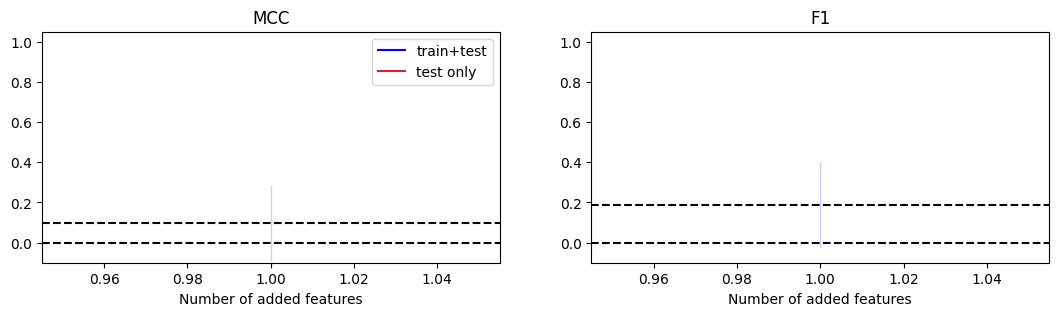

In [40]:
import numpy as np
import matplotlib.pyplot as plt

mcc_curves_train_test, f1_curves_train_test, num_feat_train_test = accur_curves(accuracy_curves_all_splits_add_feat_train_test)
mcc_curves_test, f1_curves_test, num_feat_test = accur_curves(accuracy_curves_all_splits_add_feat_test)


plt.figure(figsize=(13, 3))
plt.subplot(1, 2, 1)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(mcc_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal

x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(mcc_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
plt.axhline(y=mean_curve_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal

plt.xlabel('Number of added features')
plt.title('MCC')
plt.ylim([-0.1,1.05])
plt.legend()

plt.subplot(1, 2, 2)
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(f1_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue')#, label='Mean accuracy')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizontal

mean_curve_test, std_curve_test = find_mean_std_curve(f1_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red')#, label='Mean accuracy')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
plt.axhline(y=mean_curve_test[-1], color='black', linestyle='--')#, label='Baseline')  # horizonta

plt.xlabel('Number of added features')
plt.title('F1')
plt.ylim([-0.1,1.05])
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mcc_curves_train_test, f1_curves_train_test, num_feat_train_test = accur_curves(accuracy_curves_all_splits_rem_feat_train_test)
mcc_curves_test, f1_curves_test, num_feat_test = accur_curves(accuracy_curves_all_splits_rem_feat_test)


plt.figure(figsize=(13, 3))
plt.subplot(1, 2, 1)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(mcc_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(mcc_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

plt.xlabel('Number of removed features')
plt.title('MCC')
plt.ylim([-0.1,1.05])
plt.legend()

plt.subplot(1, 2, 2)
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(f1_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue')#, label='Mean accuracy')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

mean_curve_test, std_curve_test = find_mean_std_curve(f1_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red')#, label='Mean accuracy')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizonta

plt.xlabel('Number of removed features')
plt.title('F1')
plt.ylim([-0.1,1.05])
plt.show()


## Noisy versions of SHAP feature removal curves

In [ ]:
feat_step = 100
feat_removal = True
train_test_feat_apply_flag = True
add_rem_noise_rates = [0.1, 0.5]

filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_feat_train_test_noise_fp_{add_rem_noise_rates[0]}_fn_{add_rem_noise_rates[1]}.pkl"
accuracy_curves_all_splits_rem_feat_train_test_noise = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict, add_rem_noise_rates)

In [ ]:
feat_step = 100
feat_removal = True
train_test_feat_apply_flag = False
add_rem_noise_rates = [0.1, 0.5]

filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_feat_test_noise_fp_{add_rem_noise_rates[0]}_fn_{add_rem_noise_rates[1]}.pkl"
accuracy_curves_all_splits_rem_feat_test_noise = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict, add_rem_noise_rates)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mcc_curves_train_test, f1_curves_train_test, num_feat_train_test = accur_curves(accuracy_curves_all_splits_rem_feat_train_test_noise)
mcc_curves_test, f1_curves_test, num_feat_test = accur_curves(accuracy_curves_all_splits_rem_feat_test_noise)


plt.figure(figsize=(13, 4))
plt.subplot(1, 2, 1)
x_train_test = num_feat_train_test[0]
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(mcc_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue', label='train+test')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

x_test = num_feat_test[0]
mean_curve_test, std_curve_test = find_mean_std_curve(mcc_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red', label='test only')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

plt.xlabel('Number of removed features')
plt.title('MCC')
plt.ylim([-0.1,1.05])
plt.legend()

plt.subplot(1, 2, 2)
mean_curve_train_test, std_curve_train_test = find_mean_std_curve(f1_curves_train_test)
plt.plot(x_train_test, mean_curve_train_test, color='blue')#, label='Mean accuracy')
plt.fill_between(x_train_test, mean_curve_train_test - std_curve_train_test, mean_curve_train_test + std_curve_train_test, alpha=0.2, color='blue')#, label='±1 std')
plt.axhline(y=mean_curve_train_test[0], color='black', linestyle='--')#, label='Baseline')  # horizontal

mean_curve_test, std_curve_test = find_mean_std_curve(f1_curves_test)
plt.plot(x_test, mean_curve_test, color='tab:red')#, label='Mean accuracy')
plt.fill_between(x_test, mean_curve_test - std_curve_test, mean_curve_test + std_curve_test, alpha=0.2, color='tab:red')#, label='±1 std')
plt.axhline(y=mean_curve_test[0], color='black', linestyle='--')#, label='Baseline')  # horizonta

plt.xlabel('Number of removed features')
plt.title('F1')
plt.ylim([-0.1,1.05])

plt.suptitle(f"Accuracy measures on the noisy test with add_rem_noise_rates = {add_rem_noise_rates}")
plt.tight_layout()
plt.show()


In [10]:
# import seaborn as sns
# from itertools import combinations
# import pandas as pd

# shap_lists = []

# for split_id in all_shap_lists_dict.keys():
#     shap_lists.append(set(all_shap_lists_dict[split_id])) 
# # Number of sets
# n = len(shap_lists)

# # Compute pairwise Jaccard similarity matrix
# jaccard_matrix = np.zeros((n, n))
# jacc_idices = []
# for i in range(n):
#     for j in range(n):
#         a, b = shap_lists[i], shap_lists[j]
#         union = a | b
#         intersection = a & b
#         jaccard_index = len(intersection) / len(union) if union else 0
#         jaccard_matrix[i, j] = jaccard_index
#         if i>j:
#             jacc_idices.append(jaccard_index)
# # Create a heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(jaccard_matrix, annot=False, fmt=".2f", cmap="viridis", cbar=True,
#             xticklabels=[f"SHAP list {i}" for i in range(n)],
#             yticklabels=[f"SHAP list {i}" for i in range(n)])
# plt.title("Pairwise Jaccard Similarity Between SHAP lists")
# plt.xlabel("SHAP list Index")
# plt.ylabel("SHAP list Index")
# plt.tight_layout()
# plt.show()


In [11]:
# num_splits = len(all_shap_lists_dict.keys())

# all_cogs = sorted(set(cog for lst in all_shap_lists_dict.values() for cog in lst))
# presence_df = pd.DataFrame(0, index=all_cogs, columns=[f"Split_{i}" for i in all_shap_lists_dict])
# for i, cogs in all_shap_lists_dict.items():
#     presence_df.loc[cogs, f"Split_{i}"] = 1

# # Add frequency column
# presence_df["Frequency"] = presence_df.sum(axis=1)/num_splits

# # Sort by frequency
# presence_df_sorted = presence_df.sort_values("Frequency", ascending=False)

# import matplotlib.pyplot as plt
# import seaborn as sns


# plt.figure(figsize=(5, 8))
# sns.barplot(
#     x="Frequency",
#     y=presence_df_sorted.index,
#     data=presence_df_sorted.reset_index(),
#     hue="index",  # use index as hue to apply the palette
#     palette="viridis",
#     dodge=False,
#     legend=False
# )
# plt.xlabel("Frequency")
# plt.ylabel("COGs")
# plt.tight_layout()

# plt.savefig(f"{OUTPUT_DIRECTORY}/shap_lists_cogs.pdf", format="pdf")

In [12]:
# dict_mb_stats = defaultdict(str)
# dict_mb_stats["jaccard_aver"] = np.mean(jacc_idices)
# dict_mb_stats["jaccard_std"] = np.std(jacc_idices)
# print(f"Ave. Jaccard indec = {np.mean(jacc_idices)}; std = {np.std(jacc_idices)}")

In [13]:
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features


# all_shap_lists_dict_with_res = {}#defaultdict(int)
# mb_lengths = []  

# for split_id in all_shap_lists_dict.keys():
#     mb_lengths.append(len(all_shap_lists_dict[split_id]))
#     markov_bound = all_shap_lists_dict[split_id]
#     indices = [i for i, val in enumerate(X_column_names) if val in markov_bound]
#    # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
#     split_dict = defaultdict(str)
#     split_dict["MB"] = markov_bound[:]
#     # split_dict["cv_accuracy_scores"] = cv_accuracy_scores.copy()
#     # split_dict["test_accuracy_scores"] = test_accuracy_scores.copy()
#     all_shap_lists_dict_with_res[split_id] = split_dict.copy()



# print(f"Average SHAP list length = {np.mean(mb_lengths)}; std = {np.std(mb_lengths)}")    

In [14]:
# dict_mb_stats["mb_length_aver"] = np.mean(mb_lengths)
# dict_mb_stats["mb_length_std"] = np.std(mb_lengths)
# df = pd.DataFrame([dict_mb_stats])

# # Save to CSV
# df.to_csv(f"{OUTPUT_DIRECTORY}/shap_lists_summary.csv", index=False)
# df

In [15]:
# import math

# aver_mb_len = math.ceil(np.mean(mb_lengths))
# aver_m_names = presence_df_sorted.index[:aver_mb_len].tolist()

# with open(f"{OUTPUT_DIRECTORY}/aver_shap_list.txt", "w") as f:
#     f.write(f"{aver_m_names}\n")
        
# aver_m_names

In [16]:
# # Explore the accuracies on the averaged MB
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# acuracy_across_mb = defaultdict(list)

# for i in range(1, len(aver_m_names) + 1):
#     print(f"Processing {i} i...")
#     cv_accur_dict_splits = defaultdict(list)
#     test_accur_dict_splits = defaultdict(list)
#     test_accur_dict_splits_baseline = defaultdict(list)
#     for split_id in all_splits_dict.keys():
#         X_val_train = all_splits_dict[split_id]["X_train"]
#         y_label_train = all_splits_dict[split_id]["y_train"]
#         X_val_test = all_splits_dict[split_id]["X_test"]
#         y_label_test = all_splits_dict[split_id]["y_test"]
    
#         taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]
#         aver_m_names_local = aver_m_names[:i]
#         indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names_local]
#         cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
        
#        # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#         for accur_measure in cv_accuracy_scores.keys():
#             cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#             test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])
    
#         #Calculate the baseline accuracies
#         N_tot = len(y_label_test)
#         N_1 = sum(y_label_test).item()
#         N_0 = N_tot - N_1
#         fp = tn = N_0/2
#         tp = fn = N_1/2
    
#         if tp+fn >0:
#             pres = tp/(tp+fp)
#             recall = tp/(tp+fn)
#             f1 = 2*(pres*recall)/(pres+recall)
        
#             test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#             test_accur_dict_splits_baseline["precision"].append(pres)
#             test_accur_dict_splits_baseline["recall"].append(recall)
#             test_accur_dict_splits_baseline["f1"].append(f1)
#             test_accur_dict_splits_baseline["roc_auc"].append(0)
            
    
#     cv_accur_dict_mean = defaultdict(float)
#     cv_accur_dict_std = defaultdict(float)
#     test_accur_dict_mean = defaultdict(float)
#     test_accur_dict_std = defaultdict(float)
#     test_accur_dict_splits_baseline_mean = defaultdict(float)
#     test_accur_dict_splits_baseline_std = defaultdict(float)
#     for accur_measure in cv_accur_dict_splits.keys():
#         cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#         cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#         test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#         test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    
#         test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#         test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

#     metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
#     acuracy_across_mb[i] = metrics

# df = pd.DataFrame(acuracy_across_mb)
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_across_aver_shap.csv")

# print(df)

In [17]:
# # Explore the accuracies on the averaged MB
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# cv_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits_baseline = defaultdict(list)

# for split_id in all_splits_dict.keys():
#     print(f"Processing {split_id} split...")
#     X_val_train = all_splits_dict[split_id]["X_train"]
#     y_label_train = all_splits_dict[split_id]["y_train"]
#     X_val_test = all_splits_dict[split_id]["X_test"]
#     y_label_test = all_splits_dict[split_id]["y_test"]

#     taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]

#     indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names]
#     cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
    
#    # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#     for accur_measure in cv_accuracy_scores.keys():
#         cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#         test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])

#     #Calculate the baseline accuracies
#     N_tot = len(y_label_test)
#     N_1 = sum(y_label_test).item()
#     N_0 = N_tot - N_1
#     fp = tn = N_0/2
#     tp = fn = N_1/2

#     if tp+fn >0:
#         pres = tp/(tp+fp)
#         recall = tp/(tp+fn)
#         f1 = 2*(pres*recall)/(pres+recall)
    
#         test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#         test_accur_dict_splits_baseline["precision"].append(pres)
#         test_accur_dict_splits_baseline["recall"].append(recall)
#         test_accur_dict_splits_baseline["f1"].append(f1)
#         test_accur_dict_splits_baseline["roc_auc"].append(0)
        

# cv_accur_dict_mean = defaultdict(float)
# cv_accur_dict_std = defaultdict(float)
# test_accur_dict_mean = defaultdict(float)
# test_accur_dict_std = defaultdict(float)
# test_accur_dict_splits_baseline_mean = defaultdict(float)
# test_accur_dict_splits_baseline_std = defaultdict(float)
# for accur_measure in cv_accur_dict_splits.keys():
#     cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#     cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#     test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#     test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])

#     test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#     test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

# metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 


# df = pd.DataFrame(metrics)

# # Optionally reorder the rows
# df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_aver_shap.csv")

# print(df)

In [18]:
# # Explore the accuracies on different MB
# from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

# cv_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits_baseline = defaultdict(list)

# for split_id in all_markov_bound_dict_with_res.keys():
#     print(f"Processing {split_id} split...")
#     X_val_train = all_splits_dict[int(split_id)]["X_train"]
#     y_label_train = all_splits_dict[int(split_id)]["y_train"]
#     X_val_test = all_splits_dict[int(split_id)]["X_test"]
#     y_label_test = all_splits_dict[int(split_id)]["y_test"]

#     taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]

#     mbs = all_shap_lists_dict_with_res[split_id]['MB']
    
#     indices = [i for i, val in enumerate(X_column_names) if val in mbs]
#     cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
#    # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
#     for accur_measure in cv_accuracy_scores.keys():
#         cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
#         test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])

#     #Calculate the baseline accuracies
#     N_tot = len(y_label_test)
#     N_1 = sum(y_label_test).item()
#     N_0 = N_tot - N_1
#     fp = tn = N_0/2
#     tp = fn = N_1/2

#     if tp+fn >0:
#         pres = tp/(tp+fp)
#         recall = tp/(tp+fn)
#         f1 = 2*(pres*recall)/(pres+recall)
    
#         test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
#         test_accur_dict_splits_baseline["precision"].append(pres)
#         test_accur_dict_splits_baseline["recall"].append(recall)
#         test_accur_dict_splits_baseline["f1"].append(f1)
#         test_accur_dict_splits_baseline["roc_auc"].append(0)
        

# cv_accur_dict_mean = defaultdict(float)
# cv_accur_dict_std = defaultdict(float)
# test_accur_dict_mean = defaultdict(float)
# test_accur_dict_std = defaultdict(float)
# test_accur_dict_splits_baseline_mean = defaultdict(float)
# test_accur_dict_splits_baseline_std = defaultdict(float)
# for accur_measure in cv_accur_dict_splits.keys():
#     cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
#     cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
#     test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
#     test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])

#     test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
#     test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

# metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
# df = pd.DataFrame(metrics)

# # Optionally reorder the rows
# df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
# df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_individ_shap.csv")

# print(df)

In [19]:
# aerob_train_arr = []
# anaerob_train_arr = []
# aerob_train_perc_arr = []
# anaerob_train_perc_arr = []

# aerob_test_arr = []
# anaerob_test_arr = []
# aerob_test_perc_arr = []
# anaerob_test_perc_arr = []

# for split_id in all_splits_dict.keys():
#     y_label_train = all_splits_dict[split_id]["y_train"]
#     aerob_train = float(sum(y_label_train.cpu()))
#     anaerob_train = float(len(y_label_train.cpu()) - aerob_train)
#     aerob_train_arr.append(aerob_train)
#     anaerob_train_arr.append(anaerob_train)
#     aerob_train_perc_arr.append(100*aerob_train/(aerob_train+anaerob_train))
#     anaerob_train_perc_arr.append(100*anaerob_train/(aerob_train+anaerob_train))

#     y_label_test = all_splits_dict[split_id]["y_test"]
#     aerob_test = float(sum(y_label_test.cpu()))
#     anaerob_test = float(len(y_label_test.cpu()) - aerob_test)
#     aerob_test_arr.append(aerob_test)
#     anaerob_test_arr.append(anaerob_test)
#     aerob_test_perc_arr.append(100*aerob_test/(aerob_test+anaerob_test))
#     anaerob_test_perc_arr.append(100*anaerob_test/(aerob_test+anaerob_test))

# #'no': 0, 'yes': 1

# print(f"Aver. number of Sporul. in train = {np.mean(aerob_train_arr)}, std = {np.std(aerob_train_arr)}, which is {np.mean(aerob_train_perc_arr)} %, std = {np.std(aerob_train_perc_arr)}")
# print(f"Aver. number of Non-Sporul. in train = {np.mean(anaerob_train_arr)}, std = {np.std(anaerob_train_arr)}, which is {np.mean(anaerob_train_perc_arr)} %, std = {np.std(anaerob_train_perc_arr)}")

# print(f"Aver. number of Sporul in test = {np.mean(aerob_test_arr)}, std = {np.std(aerob_test_arr)}, which is {np.mean(aerob_test_perc_arr)} %, std = {np.std(aerob_test_perc_arr)}")
# print(f"Aver. number of Non-Sporul. in test = {np.mean(anaerob_test_arr)}, std = {np.std(anaerob_test_arr)}, which is {np.mean(anaerob_test_perc_arr)} %, std = {np.std(anaerob_test_perc_arr)}")

#### 2. PCA and tSNE projections

In this section, we visualize all points from our datasets by projecting them into 2D PCA, and tSNE spaces. This projections give us insights on the structure of the datasets. One point = one sample/genome.

First, we color the projected samples with respect to their phenotype (aerob/anaerob).

In [5]:
if not os.path.exists(OUTPUT_DIRECTORY):
    os.makedirs(OUTPUT_DIRECTORY)

In [6]:
# Concatenate train and test for the 2D visualization
y_label = torch.cat((y_label_train, y_label_test), dim=0)
X_val = torch.cat((X_val_train, X_val_test), dim=0)
if TAX_LEVEL != "random":
    taxa_group_names = taxa_group_names_train + taxa_group_names_test

In [7]:
FONTSIZE=13

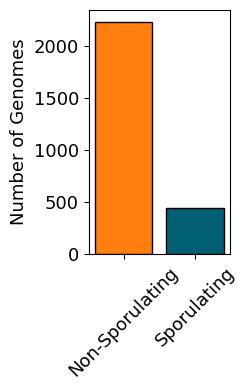

In [8]:
import matplotlib.pyplot as plt

labels = ['Non-Sporulating', 'Sporulating']

num_aerobs = sum(y_label.cpu()).item()
num_anaerobs = len(y_label.cpu()) - sum(y_label.cpu()).item()
total = num_aerobs + num_anaerobs

values = [num_anaerobs, num_aerobs]

# Plot
plt.figure(figsize=(2.5,4))
bars = plt.bar(labels, values, color=["tab:orange", "#005f73"], width=0.8, edgecolor='black')
plt.xticks(rotation=45, fontsize = FONTSIZE) 
plt.ylabel("Number of Genomes", fontsize=FONTSIZE)
#plt.ylim(0, 1)
plt.yticks([0, 500, 1000, 1500, 2000], fontsize = FONTSIZE)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/data_distrib.svg", format="svg")


Shape of the projected data = (2674, 2)


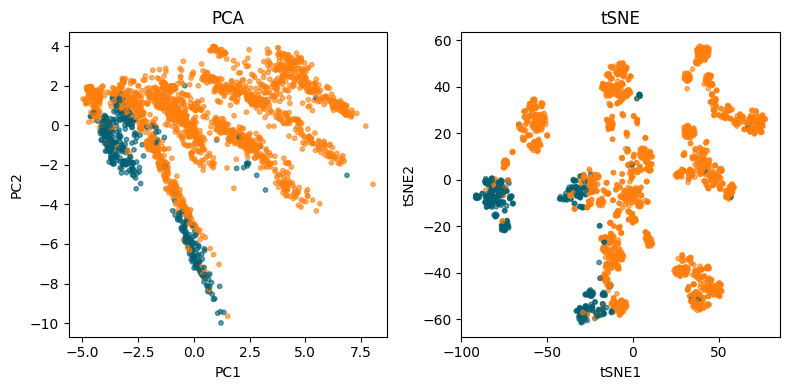

In [7]:
plt.figure(figsize=(8, 4))
legend = False
# PCA space
plt.subplot(1, 2, 1) 
n_compon = 20
colors = ListedColormap(["tab:orange", "#005f73"])
category_names = ["Non-sporulating" if yi == 0 else "Sporulating" for yi in y_label]
pca_run_and_plot(X_val.cpu(), n_compon, y_label.cpu(), category_names, colors,legend);

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_val.cpu(), 50, 100, RANDOM_SEED, y_label.cpu(), colors);

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_orig_phenot.svg", format="svg")
plt.show()

Next, we color the points with respect to the chosen taxonomy level.

Shape of the projected data = (2674, 2)


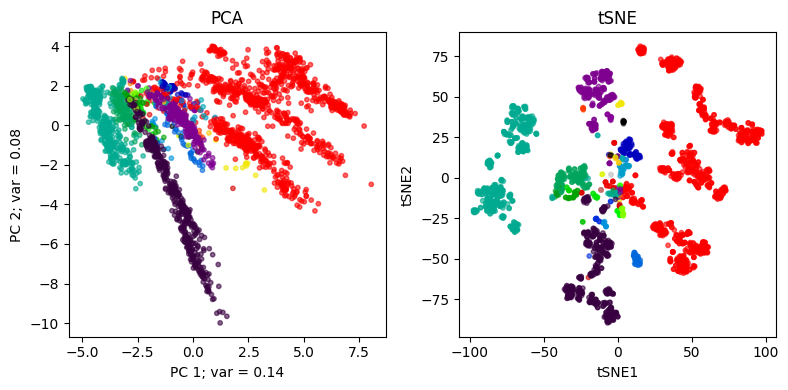

In [7]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

if TAX_LEVEL != "random":
    plt.figure(figsize=(8, 4))
    
    # Put to True, if a legend is needed (it might be too longr for some taxonomy levels)
    legend = False
    
    # PCA space
    plt.subplot(1, 2, 1) 
    n_compon = 20
    colors = ListedColormap(["black", "yellow"])
    category_names = ["anaerobe" if yi == 0 else "aerobe" for yi in y_label]
    pca_run_and_plot(X_val.cpu(), n_compon, label_encoder.fit_transform(taxa_group_names), taxa_group_names, None, legend);
    
    # t-SNE space
    plt.subplot(1, 2, 2) 
    tsne_plot(X_val.cpu(), 30, 100, RANDOM_SEED, label_encoder.fit_transform(taxa_group_names), None);
    
    # Display the plots
    plt.tight_layout()  
    plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tse_orig_phylogen.pdf", format="pdf")
    plt.show()

#### 3. XGBoost training and feature selection

In this section we train XGBoost classifier for the aerobicity phenotype prediction, and perform the feature selection analysisc based on three different methods.

First, we find the baseline (for all GOGs) test and cross-validation accuracy measures. As the accuracy measures, we use the following:

- accuracy = $\frac{TP+TN}{TP+TN+FP+FN}$,
- precision = $\frac{TP}{TP+FP}$,
- recall = $\frac{TP}{TP+FN}$,
- F1 = $2 \frac{precision \times recall}{precision + recall}$,
- ROC_AUC is the area under the curve plotting True Positive Rate ($\frac{TP}{TP+FN}$) vs False Positive Rate  ($\frac{FP}{FP+TN}$).

In [4]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
# Suppress the UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [5]:
from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features

cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)

test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"Processing {split_id} split...")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    if sum(y_label_train)/len(y_label_train) < 0.01 or  sum(y_label_test)/len(y_label_test) < 0.01:
        continue

    taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]

    cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
    for accur_measure in cv_accuracy_scores.keys():
        cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
        test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])

   # print(f"spor in train = {sum(y_label_train)/len(y_label_train)}")
   # print(f"spor in test = {sum(y_label_test)/len(y_label_test)}")    
   # print(f"f1 = {test_accuracy_scores['f1']}")

    #Calculate the baseline accuracies
    N_tot = len(y_label_test)
    N_1 = sum(y_label_test).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
        mcc = (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    
        test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
        test_accur_dict_splits_baseline["balanced_accuracy"].append(0.5)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        test_accur_dict_splits_baseline["roc_auc"].append(0)
        test_accur_dict_splits_baseline["mcc"].append(mcc)
        

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])

    test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing 0 split...
Processing 1 split...
Processing 2 split...
Processing 3 split...
Processing 4 split...
Processing 5 split...
Processing 6 split...
Processing 7 split...
Processing 8 split...
Processing 9 split...
Processing 10 split...
Processing 11 split...
Processing 12 split...
Processing 13 split...
Processing 14 split...
Processing 15 split...
Processing 16 split...
Processing 17 split...
Processing 18 split...
Processing 19 split...
Processing 20 split...
Processing 21 split...
Processing 22 split...
Processing 23 split...
Processing 24 split...
Processing 25 split...
Processing 26 split...
Processing 27 split...
Processing 28 split...
Processing 29 split...


In [6]:
metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['balanced_accuracy', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'mcc'])
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics.csv")

print(df)

                    cv mean    cv std  test mean  test std  \
balanced_accuracy  0.677060  0.059254   0.714904  0.129771   
accuracy           0.892572  0.031828   0.904446  0.071667   
precision          0.668378  0.133921   0.828302  0.263222   
recall             0.374027  0.119571   0.443205  0.270027   
f1                 0.429841  0.102466   0.534713  0.290941   
roc_auc                 NaN       NaN        NaN       NaN   
mcc                0.429841  0.102466   0.527212  0.258601   

                   test baseline mean  test baseline std  
balanced_accuracy            0.500000           0.000000  
accuracy                     0.500000           0.000000  
precision                    0.185490           0.137002  
recall                       0.500000           0.000000  
f1                           0.240773           0.150843  
roc_auc                           NaN                NaN  
mcc                          0.000000           0.000000  


In [7]:
print(f"XGBoost cv_accuracy (all features) = {cv_accur_dict_mean}")
print(f"XGBoost cv_accuracy (all features) = {cv_accur_dict_std}")
print(f"XGBoost baseline test accuracy (all features) = {test_accur_dict_mean}")
print(f"XGBoost baseline test accuracy (all features) = {test_accur_dict_std}")

XGBoost cv_accuracy (all features) = defaultdict(<class 'float'>, {'mcc': np.float64(0.4298412615458671), 'balanced_accuracy': np.float64(0.6770602762822343), 'accuracy': np.float64(0.8925719954594743), 'precision': np.float64(0.6683775499216361), 'recall': np.float64(0.37402749356847015), 'f1': np.float64(0.4298412615458671)})
XGBoost cv_accuracy (all features) = defaultdict(<class 'float'>, {'mcc': np.float64(0.10246643059990967), 'balanced_accuracy': np.float64(0.05925435104283312), 'accuracy': np.float64(0.031827768559134745), 'precision': np.float64(0.13392124768021552), 'recall': np.float64(0.11957052451785961), 'f1': np.float64(0.10246643059990967)})
XGBoost baseline test accuracy (all features) = defaultdict(<class 'float'>, {'mcc': np.float64(0.5272115699290735), 'balanced_accuracy': np.float64(0.7149044067291189), 'accuracy': np.float64(0.9044458007095155), 'precision': np.float64(0.8283023604421428), 'recall': np.float64(0.44320531756725545), 'f1': np.float64(0.5347126016753

Next, we perform feature selection. First, we rank all the features with respect to the chosen method (mutual information, random forest weigths, and SHAP) from the most to the least importan ones. Then we gradually add ranked features starting from the most important one, re-train the model and evaluate its performance. As the second test, we gradually remove features satrting from the least important ones, and evaluate the performance of the re-trained model again. The results are shown below.

As a baseline, we do this analysis for random feature ranking, i.e. we generate random feature order N times, and find the average accuracy and std across the runs for the added and removed features.

In [8]:
X_train_np = np.array(X_val_train.cpu())
X_train_transposed = X_train_np.T

/scratch/ipykernel_19580/860185482.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train_np = np.array(X_val_train.cpu())


In [9]:
import os
import pickle
import warnings

from feature_selection.feature_selection_utils import random_feat_removal_curves

file_path = os.path.join(OUTPUT_DIRECTORY, "feat_adding_curves_random.pkl")

if False:#os.path.isfile(file_path):
    print("Reading the existing file...")
    with open(file_path, "rb") as f:
        results = pickle.load(f)
        cv_accur_arr_all_runs_mn = results["cv_accur_arr_all_runs_mn"]
        cv_accur_arr_all_runs_std = results["cv_accur_arr_all_runs_std"]
        test_accur_arr_all_runs_mn = results["test_accur_arr_all_runs_mn"]
        test_accur_arr_all_runs_std = results["test_accur_arr_all_runs_std"]
        num_feat = results["num_feat"]
else:
    print("Calculating the random feature adding curves....")
    num_runs = 20
    feat_step = (int(X_val_train.shape[1]/20))
    feat_removal = False
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cv_accur_arr_all_runs_mn, cv_accur_arr_all_runs_std, test_accur_arr_all_runs_mn, test_accur_arr_all_runs_std, num_feat = random_feat_removal_curves(X_val_train, X_val_test, y_label_train, y_label_test, num_runs, feat_step, DEVICE, feat_removal, groups = taxa_group_names_train);  
        results = {
            "cv_accur_arr_all_runs_mn": cv_accur_arr_all_runs_mn,
            "cv_accur_arr_all_runs_std": cv_accur_arr_all_runs_std,
            "test_accur_arr_all_runs_mn": test_accur_arr_all_runs_mn,
            "test_accur_arr_all_runs_std": test_accur_arr_all_runs_std,
            "num_feat": num_feat,
        }
        
    # Save to a pickle file
    with open(file_path, "wb") as f:
        pickle.dump(results, f)

Calculating the random feature adding curves....
Processing random feature combo 0
Processing random feature combo 1
Processing random feature combo 2
Processing random feature combo 3
Processing random feature combo 4
Processing random feature combo 5
Processing random feature combo 6
Processing random feature combo 7
Processing random feature combo 8
Processing random feature combo 9
Processing random feature combo 10
Processing random feature combo 11
Processing random feature combo 12
Processing random feature combo 13
Processing random feature combo 14
Processing random feature combo 15
Processing random feature combo 16
Processing random feature combo 17
Processing random feature combo 18
Processing random feature combo 19


In [10]:
from feature_selection.feature_selection_utils import random_feat_removal_curves

# Find accuracy measures for random feature ordering
num_runs = 1
feat_step = 100

feat_removal = False
cv_accur_arr_all_runs_mn, cv_accur_arr_all_runs_std, test_accur_arr_all_runs_mn, test_accur_arr_all_runs_std, num_feat = random_feat_removal_curves(X_val_train, X_val_test, y_label_train, y_label_test, num_runs, feat_step, DEVICE, feat_removal);    

Processing random feature combo 0


KeyboardInterrupt: 

In [25]:
feat_removal = True
cv_accur_arr_all_runs_mn_rem, cv_accur_arr_all_runs_std_rem, test_accur_arr_all_runs_mn_rem, test_accur_arr_all_runs_std_rem, num_feat = random_feat_removal_curves(X_val_train, X_val_test, y_label_train, y_label_test, num_runs, feat_step, DEVICE, feat_removal);

#### 3.1 Feature selection with Mutual Information

In this section, we rank the features (COGs) using the mutual information. The mutual information quantifies "the amount of information one random variable contains about another".

We calculate the mutual information between each feature and the target label vector with phenotypes, and rank all the features from the largest to the smallest value.

In [55]:
from feature_selection.feature_selection_utils import mutual_info_features

sorted_cog_idx_by_mi, sorted_mi, sorted_names = mutual_info_features(X_val_train.cpu(), y_label_train.cpu(), X_column_names, RANDOM_SEED)

In [56]:
# Select the top N features
N = 10
top_N_indices = sorted_cog_idx_by_mi[:N]
top_N_mi = sorted_mi[:N]
top_N_names_by_mi = sorted_names[:N]
top_feat_mi_counts = [X_train_transposed[i] for i in sorted_cog_idx_by_mi[:N]]

print(f"Top {N} COGs:", top_N_names_by_mi)

Top 10 COGs: ['COG1191', 'COG0768', 'COG3879', 'COG1550', 'COG3973', 'COG3856', 'COG2172', 'COG0772', 'COG3688', 'COG1316']


Using the ranked features, we re-generate the PCA and tSNE projections using the top N features only. It's expected that the separation between diffetent classes become more prominent.

Shape of the projected data = (3713, 2)


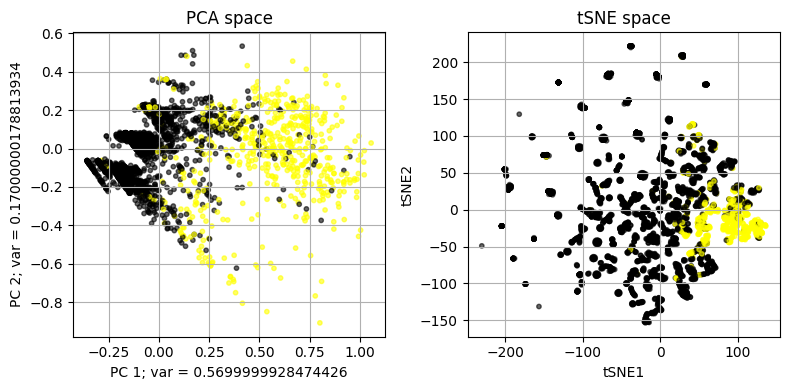

In [42]:
plt.figure(figsize=(8, 4))
X_top_feat = np.array([X_train_transposed[i] for i in sorted_cog_idx_by_mi[:N]])

# PCA space
plt.subplot(1, 2, 1) 
n_compon = 5 
colors = ListedColormap(["tab:orange", "#005f73"])
category_names = ["non-spor" if yi == 0 else "spor" for yi in y_label_train]
pca_run_and_plot(X_top_feat.T, n_compon, y_label_train.cpu(), category_names, colors);

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_top_feat.T, 10, 50, RANDOM_SEED, y_label_train.cpu(),colors);

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tse_top{N}_mi_feat.pdf", format="pdf")
plt.show()


In [59]:
X_train_np = np.array(X_val_train.cpu())
X_train_transposed = X_train_np.T
print(f"X_train_transposed shape = {X_train_transposed.shape}")

X_train_transposed shape = (4789, 2063)


In [60]:
# Select the top N features
N = 30
top_N_indices = sorted_cog_idx_by_mi[:N]
top_N_mi = sorted_mi[:N]
top_N_names_by_mi = sorted_names[:N]
top_feat_mi_counts = [X_train_transposed[i] for i in sorted_cog_idx_by_mi[:N]]

print(len(top_feat_mi_counts[0]))

print(f"Top {N} COGs:", top_N_names_by_mi)

2063
Top 30 COGs: ['COG1191', 'COG0768', 'COG3879', 'COG1550', 'COG3973', 'COG3856', 'COG2172', 'COG0772', 'COG3688', 'COG1316', 'COG2508', 'COG1994', 'COG1277', 'COG2208', 'COG1141', 'COG1131', 'COG2720', 'COG0726', 'COG1623', 'COG0791', 'COG1438', 'COG1366', 'COG1695', 'COG0766', 'COG5577', 'COG2344', 'COG5002', 'COG1799', 'COG2337', 'COG3599']


Next, we re-train XGBoost on the reduced feature sets. We begin by gradually adding the top-ranked features, starting with the one that has the highest mutual information and progressing toward the one with the lowest mutual information.

In [ ]:
feat_step = 100
feat_removal = False
cv_accur_arr, test_accur_arr, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), sorted_cog_idx_by_mi, feat_step, DEVICE, feat_removal)       

Then, we re-train XGBoost on removed top the most important features. 

In [ ]:
feat_removal = True
cv_accur_arr_rem, test_accur_arr_rem, num_feat_rem = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), sorted_cog_idx_by_mi, feat_step, DEVICE, feat_removal)       

In [16]:
print(cv_accur_arr[0])
print(test_accur_arr[0])

{'accuracy': 0.9331368789126391, 'precision': 0.9443989104008501, 'recall': 0.9595121951219511, 'f1': 0.9518444606770131, 'roc_auc': 0.9198696209978665}
{'accuracy': 0.8540540540540541, 'precision': 0.6746987951807228, 'recall': 1.0, 'f1': 0.8057553956834532, 'roc_auc': 0.9062846068660022}


The training results are visualized below.

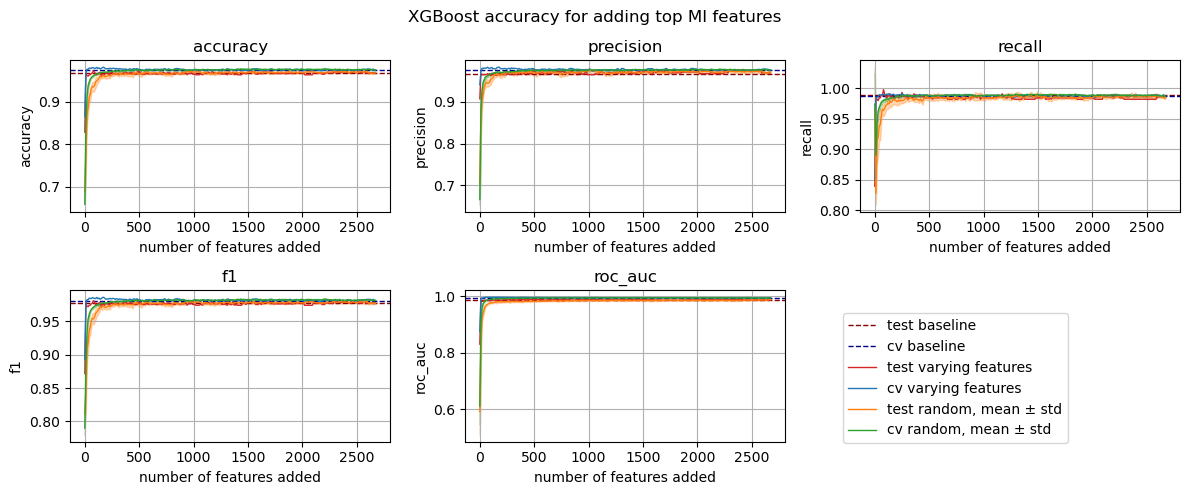

In [29]:
from feature_selection.feature_selection_utils import plot_accuracy_metric

fig = plt.figure(figsize=(12, 5))
tot_num_feat = X_val_train.cpu().shape[1]

metrics = ['accuracy','precision','recall', 'f1','roc_auc']

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plot_accuracy_metric(test_accuracy_scores[metric], cv_accuracy_scores[metric], [scores[metric] for scores in test_accur_arr], [scores[metric] for scores in cv_accur_arr], [scores[metric] for scores in test_accur_arr_all_runs_mn], [scores[metric] for scores in test_accur_arr_all_runs_std], [scores[metric] for scores in cv_accur_arr_all_runs_mn], [scores[metric] for scores in cv_accur_arr_all_runs_std], num_feat)
    plt.ylabel(metric)
    plt.title(metric)
    plt.xlabel("number of features added")
plt.tight_layout(h_pad=1.5, w_pad=2.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.9, 0.1)) 
plt.suptitle("XGBoost accuracy for adding top MI features") 
plt.savefig(f"{OUTPUT_DIRECTORY}/accuracy_mi_feat_add.pdf", format="pdf")   

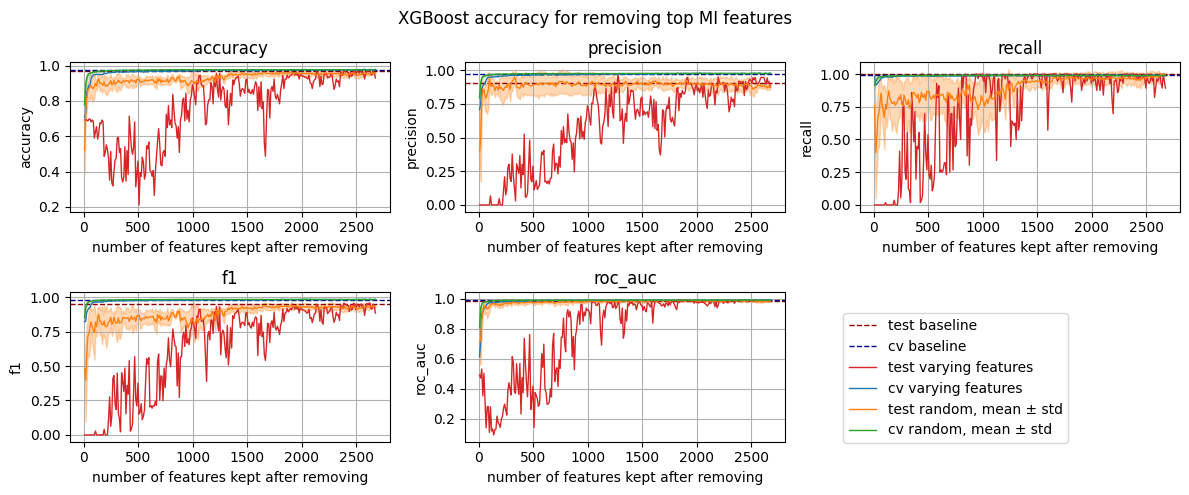

In [18]:
fig = plt.figure(figsize=(12, 5))
tot_num_feat = X_val_train.cpu().shape[1]

metrics = ['accuracy','precision','recall', 'f1','roc_auc']

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plot_accuracy_metric(test_accuracy_scores[metric], cv_accuracy_scores[metric], [scores[metric] for scores in test_accur_arr_rem], [scores[metric] for scores in cv_accur_arr_rem], [scores[metric] for scores in test_accur_arr_all_runs_mn_rem], [scores[metric] for scores in test_accur_arr_all_runs_std_rem], [scores[metric] for scores in cv_accur_arr_all_runs_mn_rem], [scores[metric] for scores in cv_accur_arr_all_runs_std_rem], [tot_num_feat - n  for n in num_feat])
    plt.ylabel(metric)
    plt.title(metric)
    plt.xlabel("number of features kept after removing")
plt.tight_layout(h_pad=1.5, w_pad=2.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.9, 0.1)) 
plt.suptitle("XGBoost accuracy for removing top MI features") 
plt.savefig(f"{OUTPUT_DIRECTORY}/accuracy_mi_feat_remov.pdf", format="pdf")  

#### 3.2 Feature selection with Random Forest

In this section, we rank the features (COGs) using random forest model. During training, the model assigns weights to each feature with respect to their importamce to the prediction task. We train random forest on the train dataset, find the weights, and rank the features with respect to the values of the weights.

The rest of the analysis is the same as the one for the mutual information.

In [33]:
from feature_selection.feature_selection_utils import random_forest_features
sorted_cog_idx_by_rand_forest, sorted_importances, sorted_names = random_forest_features(X_val_train.cpu(), y_label_train.cpu(), X_column_names, RANDOM_SEED)

Original feature count: 2677, Selected feature count: 270


In [34]:
# Select the top N features
N = 10
top_N_indices = sorted_cog_idx_by_rand_forest[:N]
top_N_importances = sorted_importances[:N]
top_N_names_by_rand_forest = sorted_names[:N]
top_feat_rand_forest_counts = [X_train_transposed[i] for i in sorted_cog_idx_by_rand_forest[:N]]
print(f"Top {N} COGs:", top_N_names_by_rand_forest)

Top 10 COGs: ['COG1328', 'COG0109', 'COG0369', 'COG0567', 'COG0026', 'COG0276', 'COG1592', 'COG0543', 'COG4624', 'COG1838']


In [35]:
X_top_feat = np.array([X_train_transposed[i] for i in sorted_cog_idx_by_rand_forest[:N]])

Shape of the projected data = (2524, 2)


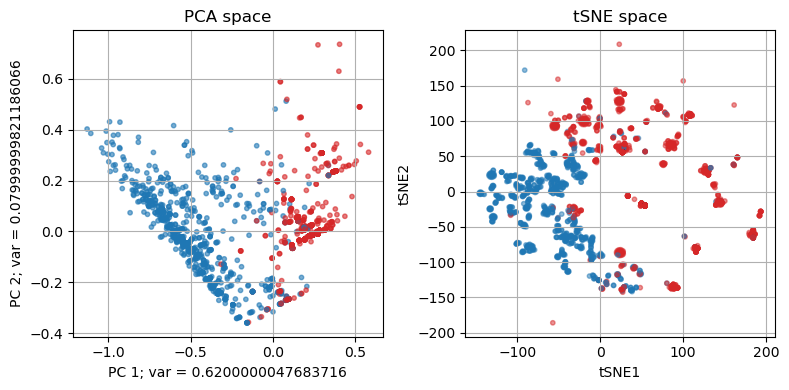

In [18]:
plt.figure(figsize=(8, 4))
colors = ListedColormap(["tab:orange", "#005f73"])
# PCA space
plt.subplot(1, 2, 1) 
n_compon = 5
pca_run_and_plot(X_top_feat.T, n_compon, y_label_train.cpu(), category_names, colors);

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_top_feat.T, 10, 50, RANDOM_SEED, y_label_train.cpu(),colors);

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tse_top{N}_randfor_feat.pdf", format="pdf")
plt.show()

In [36]:
feat_step = 10
feat_removal = False
cv_accur_arr, test_accur_arr, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), sorted_cog_idx_by_rand_forest, feat_step, DEVICE, feat_removal)       

In [37]:
print(cv_accur_arr[0])
print(test_accur_arr[0])

{'accuracy': 0.8652789564670753, 'precision': 0.9404757749441968, 'recall': 0.8498498498498499, 'f1': 0.8927884124291878, 'roc_auc': 0.874988421714248}
{'accuracy': 0.8288854003139717, 'precision': 0.9068627450980392, 'recall': 0.8390022675736961, 'f1': 0.8716136631330977, 'roc_auc': 0.8311930214262575}


In [38]:
feat_removal = True
cv_accur_arr_rem, test_accur_arr_rem, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), sorted_cog_idx_by_rand_forest, feat_step, DEVICE, feat_removal)       

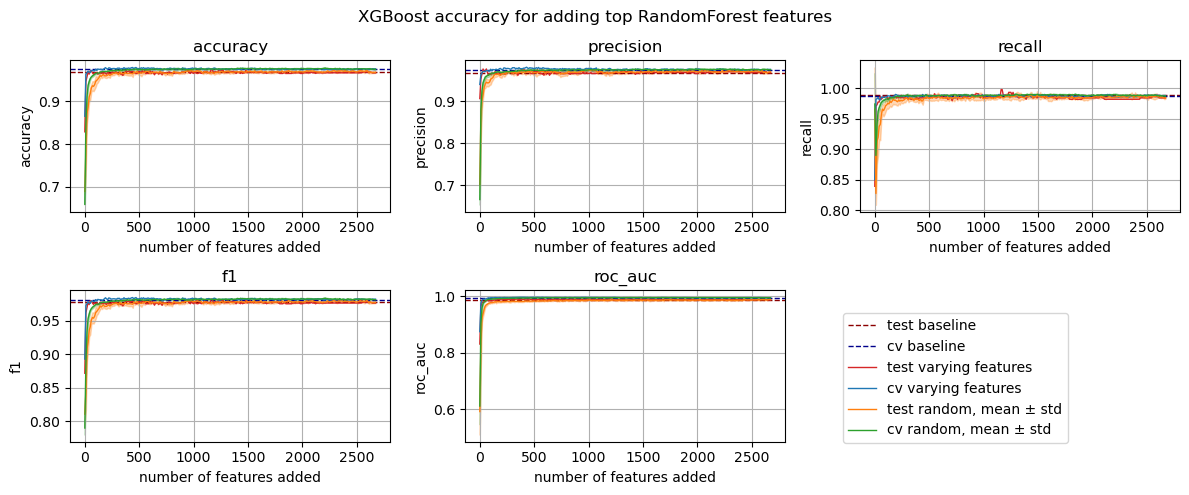

In [39]:
from feature_selection.feature_selection_utils import plot_accuracy_metric

fig = plt.figure(figsize=(12, 5))
tot_num_feat = X_val_train.cpu().shape[1]

metrics = ['accuracy','precision','recall', 'f1','roc_auc']

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plot_accuracy_metric(test_accuracy_scores[metric], cv_accuracy_scores[metric], [scores[metric] for scores in test_accur_arr], [scores[metric] for scores in cv_accur_arr], [scores[metric] for scores in test_accur_arr_all_runs_mn], [scores[metric] for scores in test_accur_arr_all_runs_std], [scores[metric] for scores in cv_accur_arr_all_runs_mn], [scores[metric] for scores in cv_accur_arr_all_runs_std], num_feat)
    plt.ylabel(metric)
    plt.title(metric)
    plt.xlabel("number of features added")
plt.tight_layout(h_pad=1.5, w_pad=2.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.9, 0.1)) 
plt.suptitle("XGBoost accuracy for adding top RandomForest features") 
plt.savefig(f"{OUTPUT_DIRECTORY}/accuracy_rand_for_feat_add.pdf", format="pdf") 

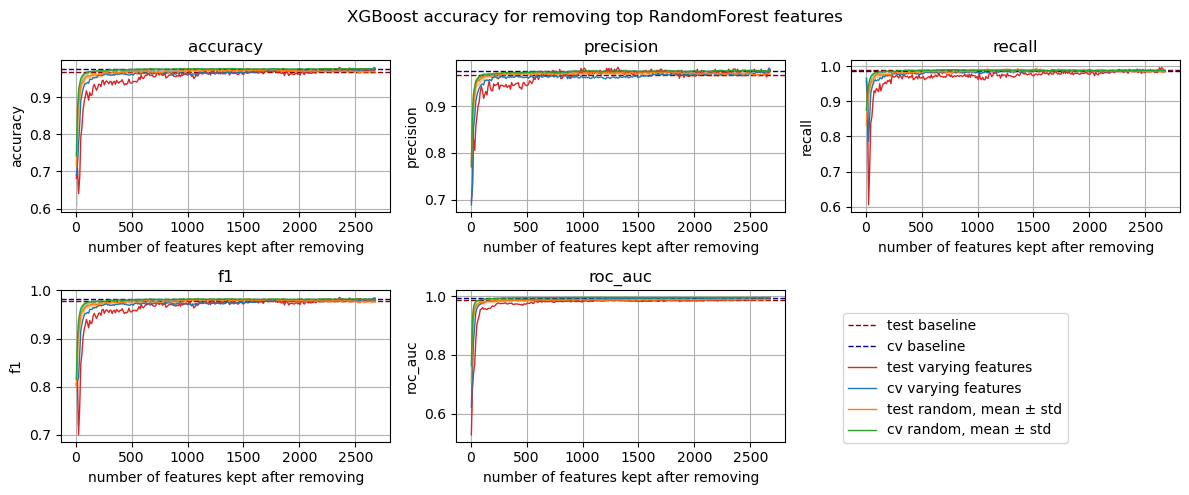

In [40]:
fig = plt.figure(figsize=(12, 5))
tot_num_feat = X_val_train.cpu().shape[1]

metrics = ['accuracy','precision','recall', 'f1','roc_auc']

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plot_accuracy_metric(test_accuracy_scores[metric], cv_accuracy_scores[metric], [scores[metric] for scores in test_accur_arr_rem], [scores[metric] for scores in cv_accur_arr_rem], [scores[metric] for scores in test_accur_arr_all_runs_mn_rem], [scores[metric] for scores in test_accur_arr_all_runs_std_rem], [scores[metric] for scores in cv_accur_arr_all_runs_mn_rem], [scores[metric] for scores in cv_accur_arr_all_runs_std_rem], [tot_num_feat - n  for n in num_feat])
    plt.ylabel(metric)
    plt.title(metric)
    plt.xlabel("number of features kept after removing")
plt.tight_layout(h_pad=1.5, w_pad=2.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.9, 0.1)) 
plt.suptitle("XGBoost accuracy for removing top RandomForest features") 
plt.savefig(f"{OUTPUT_DIRECTORY}/accuracy_rand_for_feat_remov.pdf", format="pdf")  

#### 3.3 Feature selection with SHAP values

In this section, we rank the features (COGs) with respect to their SHAP values. SHAP value for a feature is calculated by re-training a model without this feature and comparing the accuracy to the original one on the full feature set. We calculate SHAP values for all features, and rank them from the largest to the smallest.

The rest of the analysis is the same as the ones in the two previous cases.

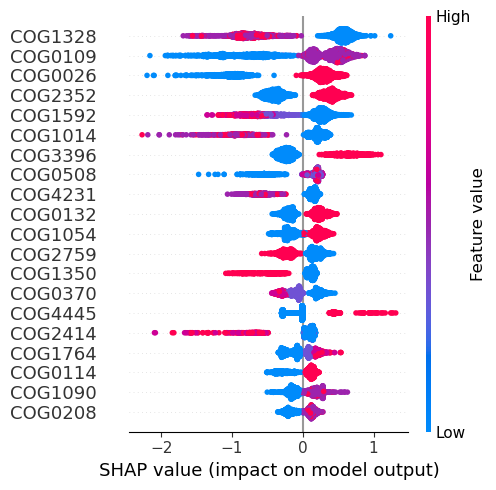

In [9]:
from feature_selection.feature_selection_utils import shap_features

device = 'cpu'
sorted_cog_idx_by_shap, sorted_shap, sorted_names = shap_features(X_val_train.cpu(), y_label_train.cpu(), X_column_names, device) 

In [10]:
# Select the top N features
N = 10
top_N_indices = sorted_cog_idx_by_shap[:N]
top_N_mi = sorted_shap[:N]
top_N_names_by_shap = sorted_names[:N]
top_feat_shap_counts = [X_train_transposed[i] for i in sorted_cog_idx_by_shap[:N]]

print(f"Top {N} COGs:", top_N_names_by_shap)

Top 10 COGs: ['COG1328', 'COG0109', 'COG0026', 'COG2352', 'COG1592', 'COG1014', 'COG3396', 'COG0508', 'COG4231', 'COG0132']


Shape of the projected data = (2524, 2)


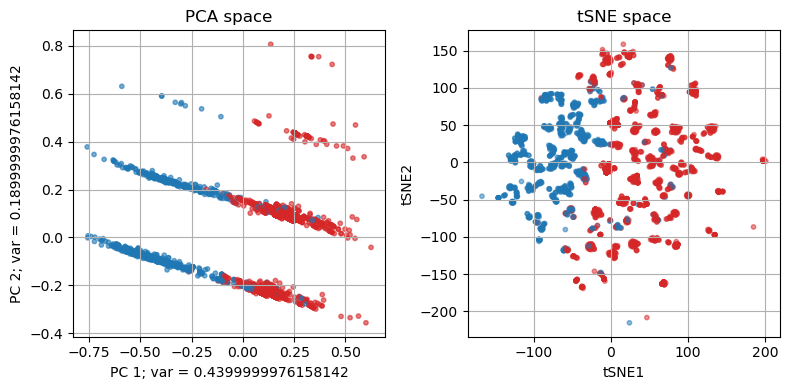

In [21]:
plt.figure(figsize=(8, 4))
X_top_feat = np.array([X_train_transposed[i] for i in sorted_cog_idx_by_shap[:N]])

# PCA space
plt.subplot(1, 2, 1) 
n_compon = 5 
pca_run_and_plot(X_top_feat.T, n_compon, y_label_train.cpu(), category_names, colors);

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_top_feat.T, 10, 50, RANDOM_SEED, y_label_train.cpu(),colors);

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tse_top{N}_shap_feat.pdf", format="pdf")
plt.show()

In [11]:
feat_step = 10
feat_removal = False
cv_accur_arr, test_accur_arr, num_feat = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), sorted_cog_idx_by_shap, feat_step, DEVICE, feat_removal)       

In [12]:
feat_removal = True
cv_accur_arr_rem, test_accur_arr_rem, num_feat_rem = xgboost_accur_select_features(X_val_train.cpu(), X_val_test.cpu(), y_label_train.cpu(), y_label_test.cpu(), sorted_cog_idx_by_shap, feat_step, DEVICE, feat_removal)       

In [26]:
num_feat = range(1,len(sorted_cog_idx_by_shap),feat_step)
len(num_feat)
feat_step

10

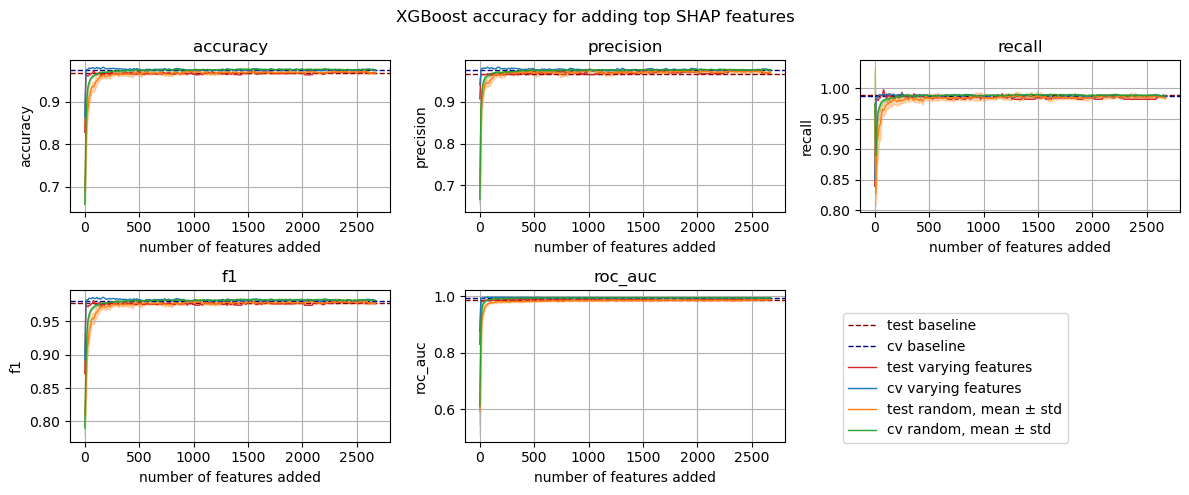

In [27]:
from feature_selection.feature_selection_utils import plot_accuracy_metric

fig = plt.figure(figsize=(12, 5))
tot_num_feat = X_val_train.cpu().shape[1]

metrics = ['accuracy','precision','recall', 'f1','roc_auc']

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plot_accuracy_metric(test_accuracy_scores[metric], cv_accuracy_scores[metric], [scores[metric] for scores in test_accur_arr], [scores[metric] for scores in cv_accur_arr], [scores[metric] for scores in test_accur_arr_all_runs_mn], [scores[metric] for scores in test_accur_arr_all_runs_std], [scores[metric] for scores in cv_accur_arr_all_runs_mn], [scores[metric] for scores in cv_accur_arr_all_runs_std], num_feat)
    plt.ylabel(metric)
    plt.title(metric)
    plt.xlabel("number of features added")
plt.tight_layout(h_pad=1.5, w_pad=2.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.9, 0.1)) 
plt.suptitle("XGBoost accuracy for adding top SHAP features") 
plt.savefig(f"{OUTPUT_DIRECTORY}/accuracy_shap_feat_add.pdf", format="pdf") 

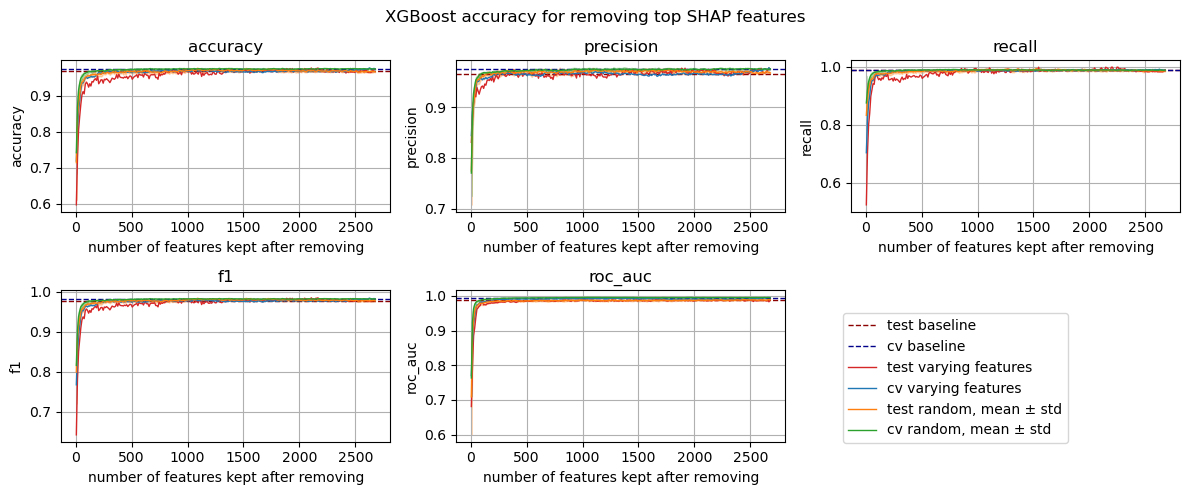

In [28]:
fig = plt.figure(figsize=(12, 5))
tot_num_feat = X_val_train.cpu().shape[1]

metrics = ['accuracy','precision','recall', 'f1','roc_auc']

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plot_accuracy_metric(test_accuracy_scores[metric], cv_accuracy_scores[metric], [scores[metric] for scores in test_accur_arr_rem], [scores[metric] for scores in cv_accur_arr_rem], [scores[metric] for scores in test_accur_arr_all_runs_mn_rem], [scores[metric] for scores in test_accur_arr_all_runs_std_rem], [scores[metric] for scores in cv_accur_arr_all_runs_mn_rem], [scores[metric] for scores in cv_accur_arr_all_runs_std_rem], [tot_num_feat - n  for n in num_feat])
    plt.ylabel(metric)
    plt.title(metric)
    plt.xlabel("number of features kept after removing")
plt.tight_layout(h_pad=1.5, w_pad=2.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.9, 0.1)) 
plt.suptitle("XGBoost accuracy for removing top SHAP features") 
plt.savefig(f"{OUTPUT_DIRECTORY}/accuracy_shap_feat_remov.pdf", format="pdf")  

#### 4. Feature comparison

In this section, we compare top of the most important features predicted with mutual information, random forest, and SHAP values between each other. The lists of the top N features should overlap..

In [35]:
import pandas as pd
from feature_selection.feature_selection_utils import make_cog_descr

# Define the data for the columns
data = {
    'MI': top_N_names_by_mi,
    'RandomForest': top_N_names_by_rand_forest,
    'SHAP': top_N_names_by_shap
}

df = pd.DataFrame(data)
make_cog_descr(df)

,MI,RandomForest,SHAP
0,COG0109: Polyprenyltransferase (heme O synthase),"COG0567: 2-oxoglutarate dehydrogenase complex,...",COG0109: Polyprenyltransferase (heme O synthase)
1,COG1612: Heme A synthase,COG0369: Flavoprotein (flavin reductase) subun...,COG0026: Phosphoribosylaminoimidazole carboxyl...
2,COG1592: Rubrerythrin,COG0508: Pyruvate/2-oxoglutarate dehydrogenase...,COG1328: Anaerobic ribonucleoside-triphosphate...
3,COG0276: Protoheme ferro-lyase (ferrochelatase),COG1328: Anaerobic ribonucleoside-triphosphate...,COG1014: Pyruvate:ferredoxin oxidoreductase or...
4,COG0026: Phosphoribosylaminoimidazole carboxyl...,COG0026: Phosphoribosylaminoimidazole carboxyl...,COG1592: Rubrerythrin
5,"COG0567: 2-oxoglutarate dehydrogenase complex,...",COG1014: Pyruvate:ferredoxin oxidoreductase or...,"COG4624: Iron only hydrogenase large subunit, ..."
6,COG0508: Pyruvate/2-oxoglutarate dehydrogenase...,COG1612: Heme A synthase,COG2352: Phosphoenolpyruvate carboxylase
7,COG0365: Acyl-coenzyme A synthetase/AMP-(fatty...,"COG4624: Iron only hydrogenase large subunit, ...",COG4231: TPP-dependent indolepyruvate ferredox...
8,COG0843: Heme/copper-type cytochrome/quinol ox...,COG1592: Rubrerythrin,COG4656: Na+-translocating ferredoxin:NAD+ oxi...
9,"COG4624: Iron only hydrogenase large subunit, ...",COG0276: Protoheme ferro-lyase (ferrochelatase),"COG3396: 1,2-phenylacetyl-CoA epoxidase, catal..."


Also, we construct a correlation matrix wetween the top features returned by each method.

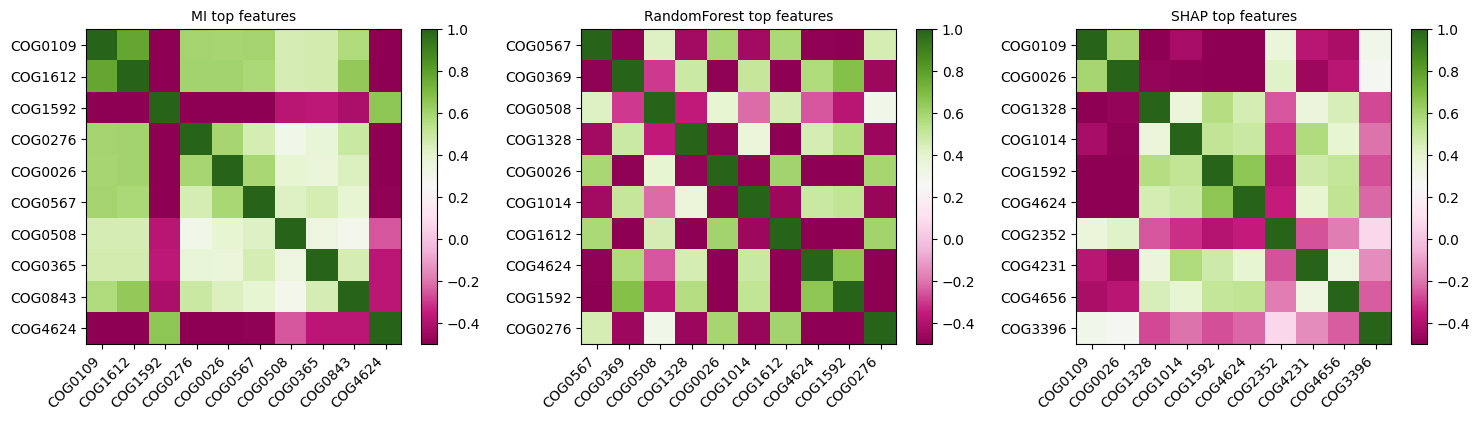

In [36]:
plt.figure(figsize=(15, 4))

vmin, vmax = -0.5, 1 #-0.6

# Correlation matrix for MI top features
plt.subplot(1, 3, 1) 
correlation_matrix = np.corrcoef(top_feat_mi_counts)
plt.imshow(correlation_matrix, vmin=vmin, vmax=vmax, cmap="PiYG")
plt.title("MI top features", fontsize=10)
plt.xticks(ticks=np.arange(len(top_N_names_by_mi)), labels=top_N_names_by_mi, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(top_N_names_by_mi)), labels=top_N_names_by_mi)
plt.colorbar()

# Correlation matrix for RandomForest top features
plt.subplot(1, 3, 2) 
correlation_matrix = np.corrcoef(top_feat_rand_forest_counts) 
plt.imshow(correlation_matrix, vmin=vmin, vmax=vmax, cmap="PiYG")
plt.title("RandomForest top features", fontsize=10)
plt.xticks(ticks=np.arange(len(top_N_names_by_rand_forest)), labels=top_N_names_by_rand_forest, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(top_N_names_by_rand_forest)), labels=top_N_names_by_rand_forest)
plt.colorbar()

# Correlation matrix for SHAP top features
plt.subplot(1, 3, 3) 
correlation_matrix = np.corrcoef(top_feat_shap_counts) 
plt.imshow(correlation_matrix, vmin=vmin, vmax=vmax, cmap="PiYG")
plt.title("SHAP top features", fontsize=10)
plt.xticks(ticks=np.arange(len(top_N_names_by_shap)), labels=top_N_names_by_shap, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(top_N_names_by_shap)), labels=top_N_names_by_shap)
plt.colorbar()

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/correlat_matr_top{N}_feat.pdf", format="pdf")
plt.show()

#### 5. Expression level of the top features

In this section, we visualize the expression level of a feature in the train samples (with respect to the feature counts). Comparison of this plot to the PCA/tSNE projections with points colored with respect to their phenotype can give insights on the feature "signal distribution" across the samples and the different phenotype groups.

In [52]:
feature_name = 'COG0369'
X_column_names = list(X_column_names)

if feature_name in X_column_names:
    idx = X_column_names.index(feature_name)
else:
    print(f"This feature doesn't exist in the feature space!")

feature_expression = X_val_train[:, idx]
feature_expression = feature_expression.cpu()

Shape of the projected data = (2524, 2)


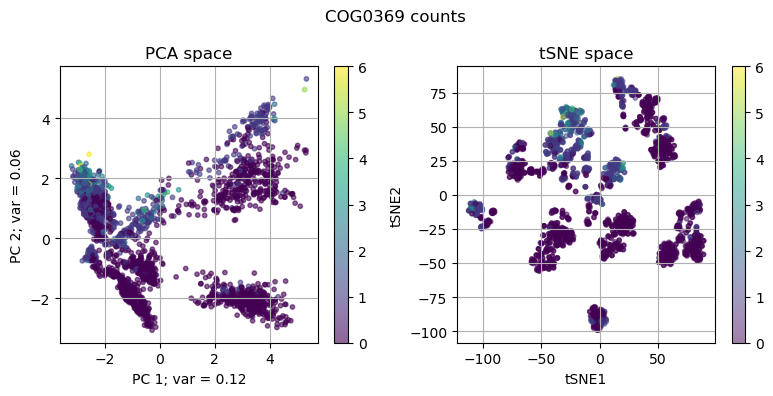

In [53]:
from matplotlib import cm
plt.figure(figsize=(8, 4))

# PCA space
plt.subplot(1, 2, 1) 
n_compon = 20
colorbar = True
colors = ListedColormap(cm.viridis(np.linspace(0, 1, len(feature_expression))))
category_names = ["anaerobe" if yi == 0 else "aerobe" for yi in y_label_train]
pca_run_and_plot(X_val_train.cpu(), n_compon, feature_expression, None, colors, legend = False, colorbar = colorbar);

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_val_train.cpu(), 30, 100, RANDOM_SEED, feature_expression, colors, colorbar = colorbar);
plt.suptitle(f"{feature_name} counts")

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_{feature_name}_feat_express_lev.pdf", format="pdf")
plt.show()